# PCA sur les embeddings de Dino

Après avoir appris un Decoder de DINOv3, sur un jeu de données DOTA

```
Image RGB (512x512)
        |
        v
+-------------------+
|  DINOv3 Backbone  |  (gele, pre-entraine)
+--------+----------+
         | 4 feature maps (extraits une seule fois, caches sur disque)
         v
+-------------------+
|   Light Decoder   |  (~500K params, entrainable)
+--------+----------+
         |
         v
Heatmap de centres (512x512)
```

Pour cette étude, nous avons pris le modèle Small-plus.
Nous avons généré des patch de différentes tailles et à différentes positions.


## Sommaire

Nous avons dans un premier temps fait une analyse des différents patch, en fonction de leurs tailles et de leurs positions d'apprentissage et d'inférence.

Dans un deuxième temps, nous avons regardé les embeddings sur les différentes couches accessibles de DINOv3 pour voir l'impact du patch sur une image.

Dans un troisième temps, nous avons réalisé des PCA, sur :

- L'image patchée vs l'image brute
- Deux images différentes pour un même patch
- Deux patch sur une même image

Dans un quatrième temps, nous avions prévu de faire un apprentissage d'un petit patch pour le "pousser" dans l'axe primaire (du PCA) d'un gros patch qui n'est pas sensible à sa position d'inférence. Mais dans la phase précédente, nous nous sommes apperçus que nous devrions avoir des informations utiles dans les couches intermédiaires de DINOv3. Nous avons observé que pour le gros patch, l'axe principal du PCA donnait la représentation de la dernière couche et que l'axe secondaire donnait la même représentation que la première couche accessible. Pour cette étude, nous avons créé un second notebook.

#### Imports

In [246]:
"""
Evaluate an adversarial patch on SegDino center detection.

Applies a trained patch to test tiles and reports per-image recall
degradation compared to clean predictions.
"""
import cv2
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm

from dataset import PreTiledDataset, mask_to_centers
from inference import find_peaks, match_centers
from train import segdino_collate
from train_patch import AdversarialPatch as AdversarialPatch1

import os

import numpy as np
import matplotlib.pyplot as plt

from train_patch5 import AdversarialPatch
from model import DINOv3Backbone, LAYER_INDICES

DATA_DIR = "data/DOTA/DOTA_PLANES_TILED"
device = "cuda" if torch.cuda.is_available() else "cpu"

#### Paramètres

#### Chargement du patch

In [261]:
def load_attacker(checkpoint, patch_path, patch_size, px, py, threshold):
    attacker1 = AdversarialPatch1(
        checkpoint_path=checkpoint,
        device=device,
        patch_size=patch_size,
        px=px, py=py,
        threshold=threshold,
    ).to(device)

    patch_data = torch.load(patch_path, map_location=device)
    attacker1.patch.data.copy_(patch_data)

    return attacker1


#### Chargement du dataset

In [260]:
def load_dataset():
    full_dataset = PreTiledDataset(DATA_DIR, split="test")

    obj_indices = []
    for i, fname in enumerate(full_dataset.images):
        mask = cv2.imread(full_dataset.mask_dir + "/" + fname, cv2.IMREAD_GRAYSCALE)
        if mask is not None and len(mask_to_centers(mask)) > 0:
            obj_indices.append(i)

    dataset = torch.utils.data.Subset(full_dataset, obj_indices)

    loader = DataLoader(
        dataset,
        batch_size=4,
        shuffle=False,
        num_workers=2,
        collate_fn=segdino_collate,
    )
    return loader

#### Evaluation

In [259]:
def evaluate_patch(attacker, loader, threshold):
    image_stats = {}

    for images, _, metas in tqdm(loader, desc="eval"):
        images = images.to(device)

        heatmaps_clean = attacker.predict_heatmaps(images)
        heatmaps_patched = attacker.predict_heatmaps_patched(images)

        for i, meta in enumerate(metas):
            gt_centers = meta["centers"]
            if not gt_centers:
                continue

            parent = meta["id"].split("_")[0]
            if parent not in image_stats:
                image_stats[parent] = {"gt": 0, "tp_clean": 0, "tp_patched": 0}

            hm_clean = heatmaps_clean[i, 0].cpu().numpy()
            hm_patched = heatmaps_patched[i, 0].cpu().numpy()

            pred_clean = find_peaks(hm_clean, threshold=threshold)
            pred_patched = find_peaks(hm_patched, threshold=threshold)

            tp_c, _, _ = match_centers(gt_centers, pred_clean)
            tp_p, _, _ = match_centers(gt_centers, pred_patched)

            image_stats[parent]["gt"] += len(gt_centers)
            image_stats[parent]["tp_clean"] += tp_c
            image_stats[parent]["tp_patched"] += tp_p

    return image_stats

#### Résultats

In [258]:
def summarize_results(image_stats):
    total_gt = total_tp_clean = total_tp_patched = 0

    print(f"{'Image':<10}| {'GT':>4} | {'clean':>5} | {'patched':>7} | recall clean → patched")
    print("-" * 60)

    for parent in sorted(image_stats):
        s = image_stats[parent]
        r_clean = s["tp_clean"] / s["gt"]
        r_patched = s["tp_patched"] / s["gt"]

        print(f"{parent:<10}| {s['gt']:>4} | {s['tp_clean']:>5} | {s['tp_patched']:>7} |   {r_clean:.2f} → {r_patched:.2f}")

        total_gt += s["gt"]
        total_tp_clean += s["tp_clean"]
        total_tp_patched += s["tp_patched"]

    r_clean = total_tp_clean / total_gt
    r_patched = total_tp_patched / total_gt

    print("-" * 60)
    print(f"{'TOTAL':<10}| {total_gt:>4} | {total_tp_clean:>5} | {total_tp_patched:>7} |   {r_clean:.2f} → {r_patched:.2f}")

    return r_clean, r_patched

In [257]:
def attack(cfg):
    loader = load_dataset()

    results = {}

    print(f"\n=== Evaluating {cfg['name']} ===")

    attacker1 = load_attacker(
        checkpoint=cfg["checkpoint"],
        patch_path=cfg["path"],
        patch_size=cfg["size"],
        px=cfg["px"],
        py=cfg["py"],
        threshold=cfg["threshold"]
    )

    stats = evaluate_patch(attacker1, loader, cfg["threshold"])
    r_clean, r_patched = summarize_results(stats)

    results[cfg["name"]] = {
        "clean": r_clean,
        "patched": r_patched,
        "drop": r_clean - r_patched
    }

### Patch 64 x 64
Ce patch a été réalisé en changeant la position du patch à chaque image d'une manière aléatoire lors de l'entrainement. Si pour une image, il est sur un avion, un nouveau tirage de la position est réalisé.

Résultat du patch en le positionnant en 0, 0

In [262]:
cfg = {
        "name": "patch64_divulse",
        "path": "attack_results/19_02-patch64_divulse-stern/patch.pt",
        "size": 64,
        "px": 0,
        "py": 0,
        "threshold": 0.3,
        "checkpoint": "runs/18_02-12_57_10_SMALL-PLUS_divulse-stern.pth"
    }

attack(cfg)


=== Evaluating patch64_divulse ===


Loading weights:   0%|          | 0/235 [00:00<?, ?it/s]

eval: 100%|██████████| 147/147 [00:38<00:00,  3.79it/s]

Image     |   GT | clean | patched | recall clean → patched
------------------------------------------------------------
P2269     |    3 |     3 |       0 |   1.00 → 0.00
P2288     |  206 |   153 |      33 |   0.74 → 0.16
P2523     |   16 |    16 |       9 |   1.00 → 0.56
P2550     |   67 |    61 |       1 |   0.91 → 0.01
P2551     |  321 |   277 |       4 |   0.86 → 0.01
P2552     |  215 |   200 |      28 |   0.93 → 0.13
P2553     |  161 |   143 |      12 |   0.89 → 0.07
P2554     |  215 |   203 |      24 |   0.94 → 0.11
P2557     |   63 |    58 |       1 |   0.92 → 0.02
P2558     |  391 |   385 |      16 |   0.98 → 0.04
P2560     |  288 |   270 |      23 |   0.94 → 0.08
P2600     |   45 |    44 |       7 |   0.98 → 0.16
P2665     |    6 |     6 |       1 |   1.00 → 0.17
P2682     |   28 |    24 |       6 |   0.86 → 0.21
P2691     |  392 |   358 |      11 |   0.91 → 0.03
P2741     |    1 |     0 |       0 |   0.00 → 0.00
P2746     |   18 |    16 |       0 |   0.89 → 0.00
P2748     | 

Le recall descend à 0.08

### Patch 64 x 64
Résultat du patch en le positionnant en 10, 10

In [270]:
cfg = {
        "name": "patch64_divulse",
        "path": "attack_results/19_02-patch64_divulse-stern/patch.pt",
        "size": 64,
        "px": 10,
        "py": 10,
        "threshold": 0.3,
        "checkpoint": "runs/18_02-12_57_10_SMALL-PLUS_divulse-stern.pth"
    }

attack(cfg)


=== Evaluating patch64_divulse ===


Loading weights:   0%|          | 0/235 [00:00<?, ?it/s]

eval: 100%|██████████| 147/147 [00:39<00:00,  3.76it/s]

Image     |   GT | clean | patched | recall clean → patched
------------------------------------------------------------
P2269     |    3 |     3 |       0 |   1.00 → 0.00
P2288     |  206 |   153 |      74 |   0.74 → 0.36
P2523     |   16 |    16 |      11 |   1.00 → 0.69
P2550     |   67 |    61 |       0 |   0.91 → 0.00
P2551     |  321 |   277 |      13 |   0.86 → 0.04
P2552     |  215 |   200 |      34 |   0.93 → 0.16
P2553     |  161 |   143 |      18 |   0.89 → 0.11
P2554     |  215 |   203 |      40 |   0.94 → 0.19
P2557     |   63 |    58 |       6 |   0.92 → 0.10
P2558     |  391 |   385 |      35 |   0.98 → 0.09
P2560     |  288 |   270 |      23 |   0.94 → 0.08
P2600     |   45 |    44 |      20 |   0.98 → 0.44
P2665     |    6 |     6 |       1 |   1.00 → 0.17
P2682     |   28 |    24 |      15 |   0.86 → 0.54
P2691     |  392 |   358 |      12 |   0.91 → 0.03
P2741     |    1 |     0 |       0 |   0.00 → 0.00
P2746     |   18 |    16 |       1 |   0.89 → 0.06
P2748     | 

Le recall descend est à 0.12 pour cette position (10, 10)

In [269]:
cfg = {
        "name": "patch64_divulse",
        "path": "attack_results/19_02-patch64_divulse-stern/patch.pt",
        "size": 64,
        "px": 400,
        "py": 400,
        "threshold": 0.3,
        "checkpoint": "runs/18_02-12_57_10_SMALL-PLUS_divulse-stern.pth"
    }

attack(cfg)


=== Evaluating patch64_divulse ===


Loading weights:   0%|          | 0/235 [00:00<?, ?it/s]

eval: 100%|██████████| 147/147 [00:39<00:00,  3.75it/s]

Image     |   GT | clean | patched | recall clean → patched
------------------------------------------------------------
P2269     |    3 |     3 |       0 |   1.00 → 0.00
P2288     |  206 |   153 |      36 |   0.74 → 0.17
P2523     |   16 |    16 |       4 |   1.00 → 0.25
P2550     |   67 |    61 |       1 |   0.91 → 0.01
P2551     |  321 |   277 |       9 |   0.86 → 0.03
P2552     |  215 |   200 |      22 |   0.93 → 0.10
P2553     |  161 |   143 |      15 |   0.89 → 0.09
P2554     |  215 |   203 |      27 |   0.94 → 0.13
P2557     |   63 |    58 |       4 |   0.92 → 0.06
P2558     |  391 |   385 |      18 |   0.98 → 0.05
P2560     |  288 |   270 |      16 |   0.94 → 0.06
P2600     |   45 |    44 |       8 |   0.98 → 0.18
P2665     |    6 |     6 |       0 |   1.00 → 0.00
P2682     |   28 |    24 |       7 |   0.86 → 0.25
P2691     |  392 |   358 |       8 |   0.91 → 0.02
P2741     |    1 |     0 |       0 |   0.00 → 0.00
P2746     |   18 |    16 |       0 |   0.89 → 0.00
P2748     | 

In [271]:
cfg = {
        "name": "patch64_divulse",
        "path": "attack_results/19_02-patch64_divulse-stern/patch.pt",
        "size": 64,
        "px": 10,
        "py": 400,
        "threshold": 0.3,
        "checkpoint": "runs/18_02-12_57_10_SMALL-PLUS_divulse-stern.pth"
    }

attack(cfg)


=== Evaluating patch64_divulse ===


Loading weights:   0%|          | 0/235 [00:00<?, ?it/s]

eval: 100%|██████████| 147/147 [00:40<00:00,  3.62it/s]

Image     |   GT | clean | patched | recall clean → patched
------------------------------------------------------------
P2269     |    3 |     3 |       0 |   1.00 → 0.00
P2288     |  206 |   153 |      59 |   0.74 → 0.29
P2523     |   16 |    16 |       8 |   1.00 → 0.50
P2550     |   67 |    61 |       2 |   0.91 → 0.03
P2551     |  321 |   277 |       7 |   0.86 → 0.02
P2552     |  215 |   200 |      34 |   0.93 → 0.16
P2553     |  161 |   143 |      13 |   0.89 → 0.08
P2554     |  215 |   203 |      30 |   0.94 → 0.14
P2557     |   63 |    58 |       3 |   0.92 → 0.05
P2558     |  391 |   385 |      13 |   0.98 → 0.03
P2560     |  288 |   270 |      21 |   0.94 → 0.07
P2600     |   45 |    44 |       8 |   0.98 → 0.18
P2665     |    6 |     6 |       1 |   1.00 → 0.17
P2682     |   28 |    24 |       6 |   0.86 → 0.21
P2691     |  392 |   358 |      19 |   0.91 → 0.05
P2741     |    1 |     0 |       0 |   0.00 → 0.00
P2746     |   18 |    16 |       0 |   0.89 → 0.00
P2748     | 

### Patch 22 x 22
Ce patch a été réalisé en restant à la position 10, 10

Résultat du patch en le positionnant en 10, 10

In [13]:
cfg = {
        "name": "patch22_divulse",
        "path": "attack_results/18_02-patch22_divulse-stern/patch.pt",
        "size": 22,
        "px": 10,
        "py": 10,
        "threshold": 0.3,
        "checkpoint": "runs/18_02-12_57_10_SMALL-PLUS_divulse-stern.pth"
    }

attack(cfg)


=== Evaluating patch22_divulse ===


Loading weights:   0%|          | 0/235 [00:00<?, ?it/s]

eval: 100%|██████████| 147/147 [00:38<00:00,  3.78it/s]

Image     |   GT | clean | patched | recall clean → patched
------------------------------------------------------------
P2269     |    3 |     3 |       0 |   1.00 → 0.00
P2288     |  206 |   153 |       0 |   0.74 → 0.00
P2523     |   16 |    16 |       0 |   1.00 → 0.00
P2550     |   67 |    61 |       0 |   0.91 → 0.00
P2551     |  321 |   277 |       0 |   0.86 → 0.00
P2552     |  215 |   200 |       0 |   0.93 → 0.00
P2553     |  161 |   143 |       0 |   0.89 → 0.00
P2554     |  215 |   203 |       0 |   0.94 → 0.00
P2557     |   63 |    58 |       0 |   0.92 → 0.00
P2558     |  391 |   385 |       0 |   0.98 → 0.00
P2560     |  288 |   270 |       0 |   0.94 → 0.00
P2600     |   45 |    44 |       0 |   0.98 → 0.00
P2665     |    6 |     6 |       0 |   1.00 → 0.00
P2682     |   28 |    24 |       0 |   0.86 → 0.00
P2691     |  392 |   358 |       0 |   0.91 → 0.00
P2741     |    1 |     0 |       0 |   0.00 → 0.00
P2746     |   18 |    16 |       0 |   0.89 → 0.00
P2748     | 

Nous observons qu'il est monstrueusement efficace. En plus, nous l'avons obtenu avec seulement 3 epoch. Mais si on change sa position d'un pixel ...

In [14]:
cfg = {
        "name": "patch22_divulse en position 11, 11",
        "path": "attack_results/18_02-patch22_divulse-stern/patch.pt",
        "size": 22,
        "px": 11,
        "py": 11,
        "threshold": 0.3,
        "checkpoint": "runs/18_02-12_57_10_SMALL-PLUS_divulse-stern.pth"
    }

attack(cfg)


=== Evaluating patch22_divulse en position 11, 11 ===


Loading weights:   0%|          | 0/235 [00:00<?, ?it/s]

eval: 100%|██████████| 147/147 [00:41<00:00,  3.57it/s]

Image     |   GT | clean | patched | recall clean → patched
------------------------------------------------------------
P2269     |    3 |     3 |       3 |   1.00 → 1.00
P2288     |  206 |   153 |     151 |   0.74 → 0.73
P2523     |   16 |    16 |      16 |   1.00 → 1.00
P2550     |   67 |    61 |      61 |   0.91 → 0.91
P2551     |  321 |   277 |     275 |   0.86 → 0.86
P2552     |  215 |   200 |     199 |   0.93 → 0.93
P2553     |  161 |   143 |     143 |   0.89 → 0.89
P2554     |  215 |   203 |     202 |   0.94 → 0.94
P2557     |   63 |    58 |      59 |   0.92 → 0.94
P2558     |  391 |   385 |     384 |   0.98 → 0.98
P2560     |  288 |   270 |     269 |   0.94 → 0.93
P2600     |   45 |    44 |      43 |   0.98 → 0.96
P2665     |    6 |     6 |       6 |   1.00 → 1.00
P2682     |   28 |    24 |      23 |   0.86 → 0.82
P2691     |  392 |   358 |     357 |   0.91 → 0.91
P2741     |    1 |     0 |       0 |   0.00 → 0.00
P2746     |   18 |    16 |      16 |   0.89 → 0.89
P2748     | 

En le décalant de un pixel, il devient alors d'une inefficacité affreusement affligeante...

### Patch 16 x 16
Ce patch a été réalisé en restant à la position 16, 16. En effet, nous nous sommes apperçus que les patch ayant pour frontière les pixel 32, convergaient plus vite que dans d'autres positions.

Résultat du patch en le positionnant en 16, 16

In [15]:
cfg = {
        "name": "patch16_divulse en position 16, 16",
        "path": "attack_results/21_02-patch16_16_divulse-stern/patch.pt",
        "size": 16,
        "px": 16,
        "py": 16,
        "threshold": 0.3,
        "checkpoint": "runs/18_02-12_57_10_SMALL-PLUS_divulse-stern.pth"
    }

attack(cfg)


=== Evaluating patch16_divulse en position 16, 16 ===


Loading weights:   0%|          | 0/235 [00:00<?, ?it/s]

eval: 100%|██████████| 147/147 [00:38<00:00,  3.78it/s]

Image     |   GT | clean | patched | recall clean → patched
------------------------------------------------------------
P2269     |    3 |     3 |       0 |   1.00 → 0.00
P2288     |  206 |   153 |       0 |   0.74 → 0.00
P2523     |   16 |    16 |       0 |   1.00 → 0.00
P2550     |   67 |    61 |       0 |   0.91 → 0.00
P2551     |  321 |   277 |       0 |   0.86 → 0.00
P2552     |  215 |   200 |       0 |   0.93 → 0.00
P2553     |  161 |   143 |       0 |   0.89 → 0.00
P2554     |  215 |   203 |       0 |   0.94 → 0.00
P2557     |   63 |    58 |       0 |   0.92 → 0.00
P2558     |  391 |   385 |       0 |   0.98 → 0.00
P2560     |  288 |   270 |       0 |   0.94 → 0.00
P2600     |   45 |    44 |       0 |   0.98 → 0.00
P2665     |    6 |     6 |       0 |   1.00 → 0.00
P2682     |   28 |    24 |       0 |   0.86 → 0.00
P2691     |  392 |   358 |       0 |   0.91 → 0.00
P2741     |    1 |     0 |       0 |   0.00 → 0.00
P2746     |   18 |    16 |       0 |   0.89 → 0.00
P2748     | 

Même patch en position (10,10)

In [16]:
cfg = {
        "name": "patch16_divulse en position 16, 16",
        "path": "attack_results/21_02-patch16_16_divulse-stern/patch.pt",
        "size": 16,
        "px": 10,
        "py": 10,
        "threshold": 0.3,
        "checkpoint": "runs/18_02-12_57_10_SMALL-PLUS_divulse-stern.pth"
    }

attack(cfg)


=== Evaluating patch16_divulse en position 16, 16 ===


Loading weights:   0%|          | 0/235 [00:00<?, ?it/s]

eval: 100%|██████████| 147/147 [00:39<00:00,  3.77it/s]

Image     |   GT | clean | patched | recall clean → patched
------------------------------------------------------------
P2269     |    3 |     3 |       3 |   1.00 → 1.00
P2288     |  206 |   153 |     154 |   0.74 → 0.75
P2523     |   16 |    16 |      16 |   1.00 → 1.00
P2550     |   67 |    61 |      61 |   0.91 → 0.91
P2551     |  321 |   277 |     274 |   0.86 → 0.85
P2552     |  215 |   200 |     200 |   0.93 → 0.93
P2553     |  161 |   143 |     143 |   0.89 → 0.89
P2554     |  215 |   203 |     202 |   0.94 → 0.94
P2557     |   63 |    58 |      60 |   0.92 → 0.95
P2558     |  391 |   385 |     384 |   0.98 → 0.98
P2560     |  288 |   270 |     269 |   0.94 → 0.93
P2600     |   45 |    44 |      43 |   0.98 → 0.96
P2665     |    6 |     6 |       6 |   1.00 → 1.00
P2682     |   28 |    24 |      23 |   0.86 → 0.82
P2691     |  392 |   358 |     354 |   0.91 → 0.90
P2741     |    1 |     0 |       0 |   0.00 → 0.00
P2746     |   18 |    16 |      16 |   0.89 → 0.89
P2748     | 

Un autre patch 16 x 16 en position (16,16)

In [17]:
cfg = {
        "name": "patch16_divulse en position 16, 16",
        "path": "attack_results/21_02-patch16_16_en16_divulse-stern/patch.pt",
        "size": 16,
        "px": 16,
        "py": 16,
        "threshold": 0.3,
        "checkpoint": "runs/18_02-12_57_10_SMALL-PLUS_divulse-stern.pth"
    }

attack(cfg)


=== Evaluating patch16_divulse en position 16, 16 ===


Loading weights:   0%|          | 0/235 [00:00<?, ?it/s]

eval: 100%|██████████| 147/147 [00:38<00:00,  3.78it/s]

Image     |   GT | clean | patched | recall clean → patched
------------------------------------------------------------
P2269     |    3 |     3 |       0 |   1.00 → 0.00
P2288     |  206 |   153 |       0 |   0.74 → 0.00
P2523     |   16 |    16 |       0 |   1.00 → 0.00
P2550     |   67 |    61 |       0 |   0.91 → 0.00
P2551     |  321 |   277 |       0 |   0.86 → 0.00
P2552     |  215 |   200 |       0 |   0.93 → 0.00
P2553     |  161 |   143 |       0 |   0.89 → 0.00
P2554     |  215 |   203 |       0 |   0.94 → 0.00
P2557     |   63 |    58 |       0 |   0.92 → 0.00
P2558     |  391 |   385 |       0 |   0.98 → 0.00
P2560     |  288 |   270 |       0 |   0.94 → 0.00
P2600     |   45 |    44 |       0 |   0.98 → 0.00
P2665     |    6 |     6 |       0 |   1.00 → 0.00
P2682     |   28 |    24 |       0 |   0.86 → 0.00
P2691     |  392 |   358 |       0 |   0.91 → 0.00
P2741     |    1 |     0 |       0 |   0.00 → 0.00
P2746     |   18 |    16 |       0 |   0.89 → 0.00
P2748     | 

Le même en position (17, 17)

In [18]:
cfg = {
        "name": "patch16_divulse en position 16, 16",
        "path": "attack_results/21_02-patch16_16_en16_divulse-stern/patch.pt",
        "size": 16,
        "px": 17,
        "py": 17,
        "threshold": 0.3,
        "checkpoint": "runs/18_02-12_57_10_SMALL-PLUS_divulse-stern.pth"
    }

attack(cfg)


=== Evaluating patch16_divulse en position 16, 16 ===


Loading weights:   0%|          | 0/235 [00:00<?, ?it/s]

eval: 100%|██████████| 147/147 [00:39<00:00,  3.75it/s]

Image     |   GT | clean | patched | recall clean → patched
------------------------------------------------------------
P2269     |    3 |     3 |       3 |   1.00 → 1.00
P2288     |  206 |   153 |     153 |   0.74 → 0.74
P2523     |   16 |    16 |      16 |   1.00 → 1.00
P2550     |   67 |    61 |      61 |   0.91 → 0.91
P2551     |  321 |   277 |     274 |   0.86 → 0.85
P2552     |  215 |   200 |     200 |   0.93 → 0.93
P2553     |  161 |   143 |     142 |   0.89 → 0.88
P2554     |  215 |   203 |     201 |   0.94 → 0.93
P2557     |   63 |    58 |      59 |   0.92 → 0.94
P2558     |  391 |   385 |     385 |   0.98 → 0.98
P2560     |  288 |   270 |     270 |   0.94 → 0.94
P2600     |   45 |    44 |      43 |   0.98 → 0.96
P2665     |    6 |     6 |       6 |   1.00 → 1.00
P2682     |   28 |    24 |      24 |   0.86 → 0.86
P2691     |  392 |   358 |     355 |   0.91 → 0.91
P2741     |    1 |     0 |       0 |   0.00 → 0.00
P2746     |   18 |    16 |      16 |   0.89 → 0.89
P2748     | 

#### Patch 12 x 12

In [19]:
cfg = {
        "name": "patch12_divulse en position 20, 20",
        "path": "attack_results/24_02-patch12_divulse-stern/patch.pt",
        "size": 12,
        "px": 20,
        "py": 20,
        "threshold": 0.3,
        "checkpoint": "runs/18_02-12_57_10_SMALL-PLUS_divulse-stern.pth"
    }

attack(cfg)


=== Evaluating patch12_divulse en position 20, 20 ===


Loading weights:   0%|          | 0/235 [00:00<?, ?it/s]

eval: 100%|██████████| 147/147 [00:39<00:00,  3.73it/s]

Image     |   GT | clean | patched | recall clean → patched
------------------------------------------------------------
P2269     |    3 |     3 |       0 |   1.00 → 0.00
P2288     |  206 |   153 |       0 |   0.74 → 0.00
P2523     |   16 |    16 |       4 |   1.00 → 0.25
P2550     |   67 |    61 |       0 |   0.91 → 0.00
P2551     |  321 |   277 |       0 |   0.86 → 0.00
P2552     |  215 |   200 |       0 |   0.93 → 0.00
P2553     |  161 |   143 |       0 |   0.89 → 0.00
P2554     |  215 |   203 |       0 |   0.94 → 0.00
P2557     |   63 |    58 |       0 |   0.92 → 0.00
P2558     |  391 |   385 |       0 |   0.98 → 0.00
P2560     |  288 |   270 |       0 |   0.94 → 0.00
P2600     |   45 |    44 |       0 |   0.98 → 0.00
P2665     |    6 |     6 |       0 |   1.00 → 0.00
P2682     |   28 |    24 |       0 |   0.86 → 0.00
P2691     |  392 |   358 |      16 |   0.91 → 0.04
P2741     |    1 |     0 |       0 |   0.00 → 0.00
P2746     |   18 |    16 |       0 |   0.89 → 0.00
P2748     | 

Le patch 12 x 12 commence à montrer ces limites

Nous avons aussi réalisé des essais en tournant le patch 22x22 de 180° et en le placant en diagonale de l'image pour conserver sa symmétrie. Sans succès. Si il nous reste du temps, nous l'intégrerons à ce notebook.

## Part II : Analyse des embeddings de DINOv3

Nous avons fait cette analyse pour toutes les images mais nous avons fait un focus sur une seule image dans ce notebook

In [ ]:
# import os
# import cv2
# import torch
# import numpy as np
# import matplotlib.pyplot as plt
# from tqdm import tqdm
# from torch.utils.data import DataLoader

# from dataset import PreTiledDataset, mask_to_centers
# from inference import find_peaks, match_centers
# from train import segdino_collate
# from train_patch5 import AdversarialPatch
# from model import DINOv3Backbone, LAYER_INDICES

In [223]:
def get_dino_embeddings(attacker, images, model_size):
    layer_ids = LAYER_INDICES[model_size]
    with torch.no_grad():
        feats = attacker.backbone.get_intermediate_layers(images, layer_ids)
    return feats

In [224]:
def load_single_image(image_id, data_dir):
    """
    Charge une seule tuile depuis PreTiledDataset.
    Retourne :
      - img : (1,3,H,W)
      - meta : dict contenant 'centers', 'id', etc.
    """
    dataset = PreTiledDataset(data_dir, split="test")

    filename = image_id + ".png"
    if filename not in dataset.images:
        raise ValueError(f"Image {filename} non trouvée dans {data_dir}")

    idx = dataset.images.index(filename)
    img, _, meta = dataset[idx]
    return img.unsqueeze(0), meta

In [225]:
def visualize_all_with_centers_no_save(
    img_clean, img_patch,
    feats_clean, feats_patch,
    centers_clean, centers_patch,
    tile_id=None
):
    fig, axes = plt.subplots(2, 3, figsize=(10, 8))
    axes = axes.flatten()

    # ---------------------------
    # 0) Calcul des avions perdus / nouveaux
    # ---------------------------
    set_clean = set((x, y) for x, y in centers_clean)
    set_patch = set((x, y) for x, y in centers_patch)

    lost = set_clean - set_patch
    new  = set_patch - set_clean
    kept = set_clean & set_patch

    # ---------------------------
    # 1) Image clean
    # ---------------------------
    clean_np = img_clean[0].detach().permute(1,2,0).cpu().numpy()
    clean_np = (clean_np - clean_np.min()) / (clean_np.max() - clean_np.min())
    axes[0].imshow(clean_np)
    for (x, y) in centers_clean:
        axes[0].scatter(x, y, s=40, c="red")
    axes[0].set_title("Clean + centres")
    axes[0].axis("off")

    # ---------------------------
    # 2) Image patchée
    # ---------------------------
    patch_np = img_patch[0].detach().permute(1,2,0).cpu().numpy()
    patch_np = (patch_np - patch_np.min()) / (patch_np.max() - patch_np.min())
    axes[1].imshow(patch_np)

    for (x, y) in kept:
        axes[1].scatter(x, y, s=40, c="blue")

    # for (x, y) in lost:
    #     axes[1].scatter(x, y, s=80, c="red", marker="x", linewidths=2)

    for (x, y) in new:
        axes[1].scatter(x, y, s=80, c="green", marker="s")

    axes[1].set_title("Patchée + centres (détectés en bleu)")
    axes[1].axis("off")

    # ---------------------------
    # 3–6) Différences embeddings + L2 + Cosine
    # ---------------------------
    for li in range(4):
        f1 = feats_clean[li][0].detach()
        f2 = feats_patch[li][0].detach()

        # L2 global
        l2 = (f1 - f2).norm(dim=-1).mean().item()

        # Cosine similarity global
        cos = torch.nn.functional.cosine_similarity(
            f1.flatten(0), f2.flatten(0), dim=0
        ).item()

        # Carte 32×32
        C = f1.shape[-1]
        f1_2d = f1.permute(1,0).reshape(C, 32, 32)
        f2_2d = f2.permute(1,0).reshape(C, 32, 32)
        diff_map = (f1_2d - f2_2d).norm(dim=0).cpu().numpy()

        axes[li+2].imshow(diff_map, cmap="inferno")
        axes[li+2].set_title(
            f"Layer {li}\nL2={l2:.3f} | Cos={cos:.3f}"
        )
        axes[li+2].axis("off")

    plt.tight_layout()
    plt.show()

In [226]:
def compare_embeddings(feats_clean, feats_patch):
    l2_diffs = []
    cos_sims = []

    for f1, f2 in zip(feats_clean, feats_patch):
        l2 = (f1 - f2).norm(dim=-1).mean().item()
        l2_diffs.append(l2)

        cos = torch.nn.functional.cosine_similarity(
            f1.flatten(1), f2.flatten(1)
        ).mean().item()
        cos_sims.append(cos)

    return l2_diffs, cos_sims

In [227]:
def eval_patch_2(attacker, img, meta, threshold=0.3, return_embeddings=False):
    """
    Évalue un patch adversarial sur UNE SEULE image.

    Arguments :
        attacker : instance d'AdversarialPatch déjà configurée
        img      : tenseur (1,3,H,W)
        meta     : dictionnaire contenant 'centers' et 'id'
        threshold: seuil de détection
        return_embeddings : si True, renvoie feats_clean et feats_patch

    Retour :
        stats : {
            "gt": nombre de centres GT,
            "tp_clean": TP clean,
            "tp_patched": TP patched,
            "pred_clean": liste centres clean,
            "pred_patched": liste centres patchés
        }
        + embeddings si demandé
    """

    # --- Ground truth ---
    gt_centers = meta["centers"]

    # --- Clean heatmap ---
    heatmap_clean = attacker.predict_heatmaps(img)[0, 0].detach().cpu().numpy()
    pred_clean = find_peaks(heatmap_clean, threshold=threshold)

    # --- Patch application ---
    centers_list = [pred_clean]  # batch=1
    img_patch = attacker.apply_patch(img, centers_list)

    # --- Patched heatmap ---
    heatmap_patched = attacker.predict_heatmaps(img_patch)[0, 0].detach().cpu().numpy()
    pred_patched = find_peaks(heatmap_patched, threshold=threshold)

    # --- Matching ---
    tp_clean, _, _ = match_centers(gt_centers, pred_clean)
    tp_patched, _, _ = match_centers(gt_centers, pred_patched)

    stats = {
        "gt": len(gt_centers),
        "tp_clean": tp_clean,
        "tp_patched": tp_patched,
        "pred_clean": pred_clean,
        "pred_patched": pred_patched,
        "img_patch": img_patch,
    }

    # --- Embeddings optionnels ---
    if return_embeddings:
        feats_clean = get_dino_embeddings(attacker, img, attacker.model_size)
        feats_patch = get_dino_embeddings(attacker, img_patch, attacker.model_size)
        stats["feats_clean"] = feats_clean
        stats["feats_patch"] = feats_patch

    return stats

In [228]:
def summarize_results(image_stats):
    print(f"{'Image':<10}| {'GT':>4} | {'clean':>5} | {'patched':>7} | recall clean → patched")
    print("-" * 60)

    total_gt = total_tp_clean = total_tp_patched = 0

    for parent, s in sorted(image_stats.items()):
        r_clean = s["tp_clean"] / s["gt"]
        r_patched = s["tp_patched"] / s["gt"]
        print(f"{parent:<10}| {s['gt']:>4} | {s['tp_clean']:>5} | {s['tp_patched']:>7} |   {r_clean:.2f} → {r_patched:.2f}")

        total_gt += s["gt"]
        total_tp_clean += s["tp_clean"]
        total_tp_patched += s["tp_patched"]

    r_clean = total_tp_clean / total_gt
    r_patched = total_tp_patched / total_gt

    print("-" * 60)
    print(f"{'TOTAL':<10}| {total_gt:>4} | {total_tp_clean:>5} | {total_tp_patched:>7} |   {r_clean:.2f} → {r_patched:.2f}")

In [229]:
def visu_embeddings(cfg):
    device = cfg.get("device", "cuda" if torch.cuda.is_available() else "cpu")

    # Charger l’image
    img, meta = load_single_image(cfg["image_id"], cfg["data_dir"])
    print("Image shape:", img.shape)
    px, py = cfg["px"], cfg["py"]
    size = cfg["size"]

    # img est en (C, H, W)
    #img = img.squeeze(0)
    _, C, H, W = img.shape

    x1, x2 = px, min(px + size, W)
    y1, y2 = py, min(py + size, H)

    img[:, :, y1:y2, x1:x2] = 0.0
    img = img.to(device)
    # Charger l’attaquant
    attacker = AdversarialPatch(
        checkpoint_path=cfg["checkpoint"],
        device=device,
        patch_size=cfg["size"],
        px=cfg["px"],
        py=cfg["py"],
        threshold=cfg["threshold"],
        model_size=cfg.get("model_size", "small-plus"),
    ).to(device)

    patch_data = torch.load(cfg["path"], map_location=device)
    attacker.patch.data.copy_(patch_data)

    # Évaluer sur une seule image
    stats = eval_patch_2(
        attacker,
        img,
        meta,
        threshold=cfg["threshold"],
        return_embeddings=True
    )

    return stats, img, meta

In [230]:
from sklearn.decomposition import PCA
def visualize_pca_layer3_with_contrib(feat_clean, feat_patch):
    layer = 3  # uniquement la couche 3

    # --- Extraction des embeddings ---
    f1 = feat_clean[layer][0].detach().cpu().numpy()   # (1024, C)
    f2 = feat_patch[layer][0].detach().cpu().numpy()

    # --- PCA ---
    pca = PCA(n_components=2)
    pca.fit(np.concatenate([f1, f2], axis=0))

    proj_clean = pca.transform(f1)
    proj_patch = pca.transform(f2)

    # --- Variance expliquée ---
    explained = pca.explained_variance_ratio_

    # --- Charges PCA (loadings) ---
    loadings = pca.components_  # shape (2, C)

    # Top 10 contributeurs pour PC0 et PC1
    top10_pc0 = np.argsort(np.abs(loadings[0]))[::-1][:10]
    top10_pc1 = np.argsort(np.abs(loadings[1]))[::-1][:10]

    # --- Figure globale ---
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # ---------------------------
    # 1) PCA clean vs patch
    # ---------------------------
    axes[0].scatter(proj_clean[:,0], proj_clean[:,1], s=8, c='blue', label="clean")
    axes[0].scatter(proj_patch[:,0], proj_patch[:,1], s=8, c='red', label="patch")
    axes[0].set_title("PCA — Layer 3 (Clean vs Patch)")
    axes[0].set_xlabel("PC0")
    axes[0].set_ylabel("PC1")
    axes[0].legend()
    axes[0].grid(True)

    # ---------------------------
    # 2) Contribution de chaque axe (variance expliquée)
    # ---------------------------
    axes[1].bar(["PC0", "PC1"], explained, color=["#1f77b4", "#ff7f0e"])
    axes[1].set_title("Variance expliquée (Layer 3)")
    axes[1].set_ylabel("Ratio")
    axes[1].set_ylim(0, 1)

    # ---------------------------
    # 3) Top 10 contributeurs
    # ---------------------------
    axes[2].barh(
        [f"dim {i}" for i in top10_pc0[::-1]],
        np.abs(loadings[0][top10_pc0])[::-1],
        color="#1f77b4",
        label="PC0"
    )
    axes[2].barh(
        [f"dim {i}" for i in top10_pc1[::-1]],
        np.abs(loadings[1][top10_pc1])[::-1],
        color="#ff7f0e",
        alpha=0.7,
        label="PC1"
    )
    axes[2].set_title("Top 10 contributeurs (Layer 3)")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

#### Patch 22 x 22

en position (10, 10)

Image shape: torch.Size([1, 3, 512, 512])


Loading weights:   0%|          | 0/235 [00:00<?, ?it/s]

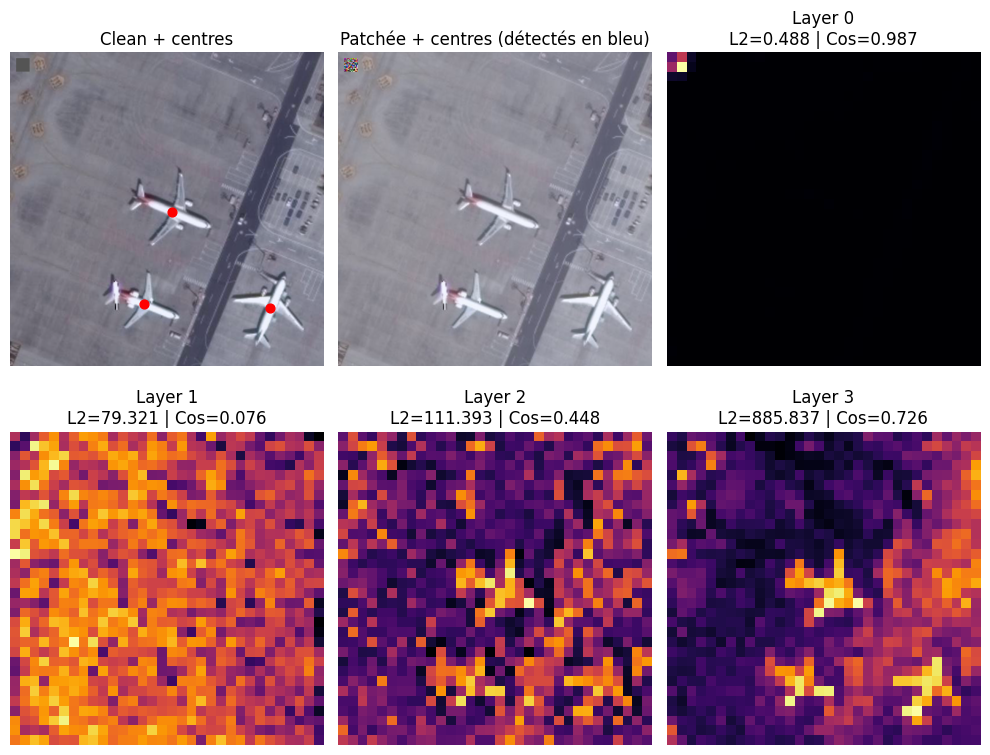

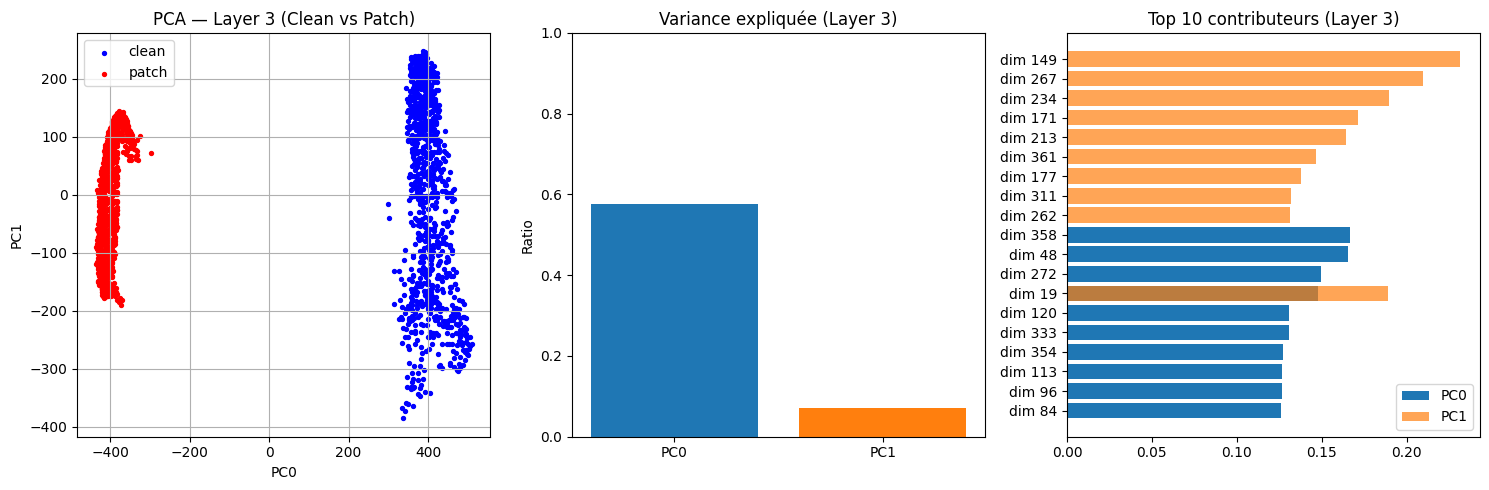

In [231]:
cfg2 = {
    "name": "patch22_divulse",
    "path": "attack_results/18_02-patch22_divulse-stern/patch.pt",
    "size": 22,
    "px": 10,
    "py": 10,
    "threshold": 0.3,
    "checkpoint": "runs/18_02-12_57_10_SMALL-PLUS_divulse-stern.pth",
    "image_id": "P2550_obj_6",
    "data_dir": "data/DOTA/DOTA_PLANES_TILED",
    "model_size": "small-plus",
    "device": "cuda",
    "return_embeddings": True
}
stats_22_img6, img, meta = visu_embeddings(cfg2)
stats = stats_22_img6
visualize_all_with_centers_no_save(
    img_clean = img,
    img_patch = stats["img_patch"],
    feats_clean = stats["feats_clean"],
    feats_patch = stats["feats_patch"],
    centers_clean = stats["pred_clean"],
    centers_patch = stats["pred_patched"],
    tile_id = cfg2["image_id"]
)
visualize_pca_layer3_with_contrib(
    stats["feats_clean"],
    stats["feats_patch"]
)


Nous observons que le patch 22x22 à la position (10,10) est efficace (2ème photo).

Nous voyons la différence des embeddings entre la photo patchée et non patchée sur les 4 autres images. Sur la première couche accèssible, nous voyons clairement le patch. Et sur la dernière nous pouvons soupçonner les avions qui ont disparu des embeddings.

Nous pouvons voir que la cos similarité est proche. Par contre la distance L2 est importante, ce que nous avons analysé comme une "disparition des avions" pour DINOv3.

Pour la PCA entre les deux images, nous observons quelle est bien séparée. Nous envisageons que l'axe principale donne présence d'avion. Par contre sur l'axe secondaire, on doit perdre de l'information avec l'image patchée. La composante principale est à loins de 60%.

#### Patch 64 x 64

Image shape: torch.Size([1, 3, 512, 512])


Loading weights:   0%|          | 0/235 [00:00<?, ?it/s]

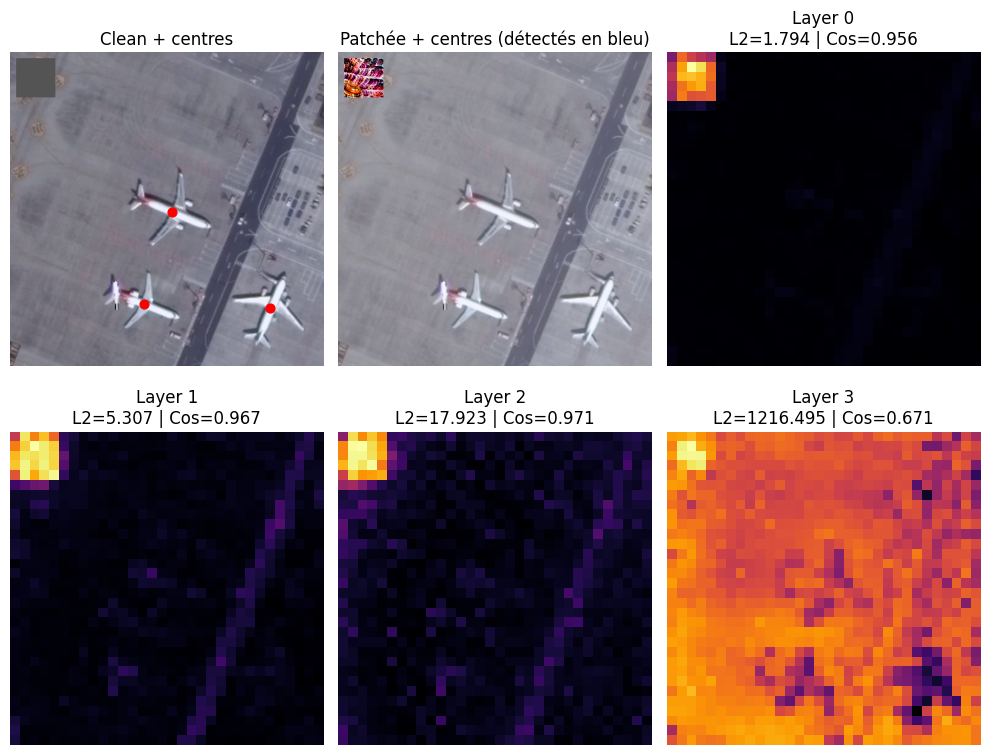

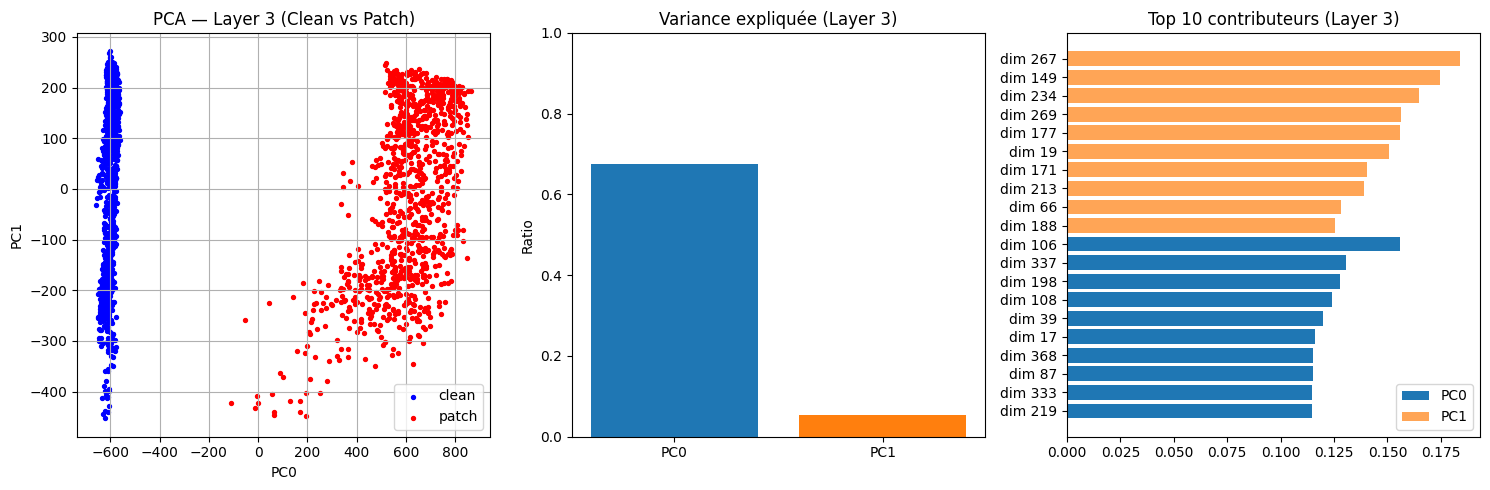

In [232]:
cfg2 = {
    "name": "patch64_divulse",
    "path": "attack_results/19_02-patch64_divulse-stern/patch.pt",
    "size": 64,
    "px": 10,
    "py": 10,
    "threshold": 0.3,
    "checkpoint": "runs/18_02-12_57_10_SMALL-PLUS_divulse-stern.pth",
    "image_id": "P2550_obj_6",
    "data_dir": "data/DOTA/DOTA_PLANES_TILED",
    "model_size": "small-plus",
    "device": "cuda",
    "return_embeddings": True
}
stats_64_img6, img, meta = visu_embeddings(cfg2)
stats = stats_64_img6
visualize_all_with_centers_no_save(
    img_clean = img,
    img_patch = stats["img_patch"],
    feats_clean = stats["feats_clean"],
    feats_patch = stats["feats_patch"],
    centers_clean = stats["pred_clean"],
    centers_patch = stats["pred_patched"],
    tile_id = cfg2["image_id"]
)
visualize_pca_layer3_with_contrib(
    stats["feats_clean"],
    stats["feats_patch"]
)

Pour la PCA, nous observons que tous les points ne sont pas bien séparés. Cela peut expliquer la mauvaise performance du patch sur certaine images.

Par contre, la composante principale est à 70%. Est-ce pour cela que ce patch est peu sensible à sa position? 

Sur une autre image

Image shape: torch.Size([1, 3, 512, 512])


Loading weights:   0%|          | 0/235 [00:00<?, ?it/s]

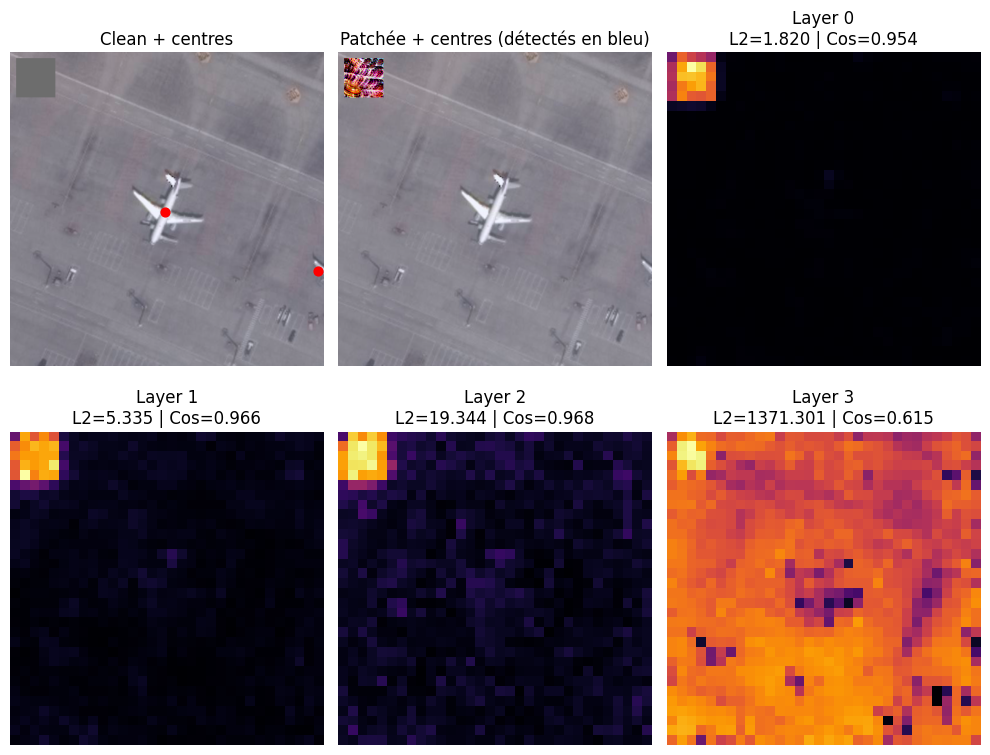

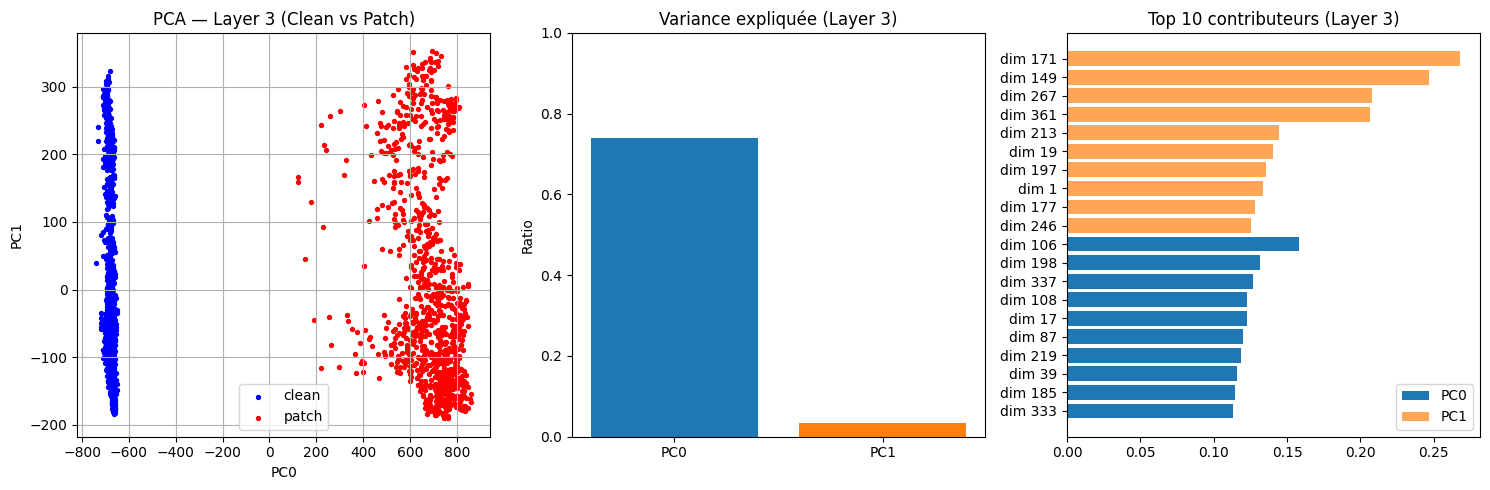

In [233]:
cfg2 = {
    "name": "patch64_divulse",
    "path": "attack_results/19_02-patch64_divulse-stern/patch.pt",
    "size": 64,
    "px": 10,
    "py": 10,
    "threshold": 0.3,
    "checkpoint": "runs/18_02-12_57_10_SMALL-PLUS_divulse-stern.pth",
    "image_id": "P2550_obj_17",
    "data_dir": "data/DOTA/DOTA_PLANES_TILED",
    "model_size": "small-plus",
    "device": "cuda",
    "return_embeddings": True
}
stats_64_img17, img, meta = visu_embeddings(cfg2)
stats = stats_64_img17
visualize_all_with_centers_no_save(
    img_clean = img,
    img_patch = stats["img_patch"],
    feats_clean = stats["feats_clean"],
    feats_patch = stats["feats_patch"],
    centers_clean = stats["pred_clean"],
    centers_patch = stats["pred_patched"],
    tile_id = cfg2["image_id"]
)
visualize_pca_layer3_with_contrib(
    stats["feats_clean"],
    stats["feats_patch"]
)

#### Patch 22 x 22

en position (11, 11)

Image shape: torch.Size([1, 3, 512, 512])


Loading weights:   0%|          | 0/235 [00:00<?, ?it/s]

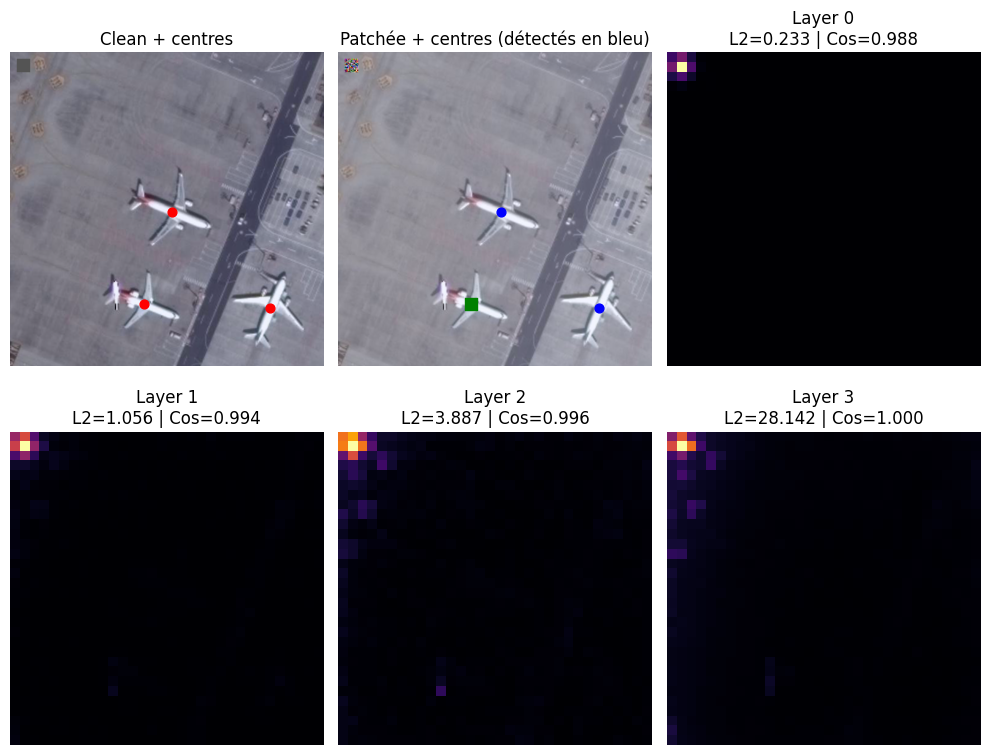

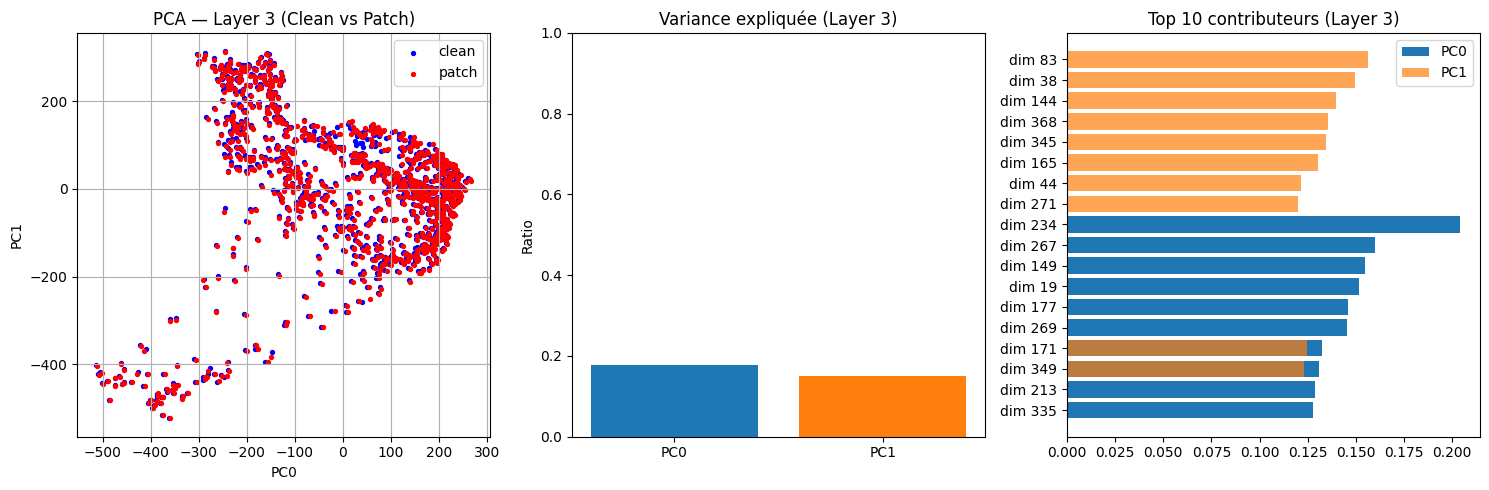

In [234]:
cfg2 = {
    "name": "patch22_divulse",
    "path": "attack_results/18_02-patch22_divulse-stern/patch.pt",
    "size": 22,
    "px": 11,
    "py": 11,
    "threshold": 0.3,
    "checkpoint": "runs/18_02-12_57_10_SMALL-PLUS_divulse-stern.pth",
    "image_id": "P2550_obj_6",
    "data_dir": "data/DOTA/DOTA_PLANES_TILED",
    "model_size": "small-plus",
    "device": "cuda",
    "return_embeddings": True
}
stats_22_pos11_img6, img, meta = visu_embeddings(cfg2)
stats = stats_22_pos11_img6
visualize_all_with_centers_no_save(
    img_clean = img,
    img_patch = stats["img_patch"],
    feats_clean = stats["feats_clean"],
    feats_patch = stats["feats_patch"],
    centers_clean = stats["pred_clean"],
    centers_patch = stats["pred_patched"],
    tile_id = cfg2["image_id"]
)
visualize_pca_layer3_with_contrib(
    stats["feats_clean"],
    stats["feats_patch"]
)

Nous pouvons observer que le patch est observé mais qu'il n'est pas diffusé aux couches supérieures.

Pour la PCA, aucun point n'est séparé. Donc pour la modèle, ces images sont identiques

#### Patch 16 x 16

Patch 1 en position (16, 16)

Image shape: torch.Size([1, 3, 512, 512])


Loading weights:   0%|          | 0/235 [00:00<?, ?it/s]

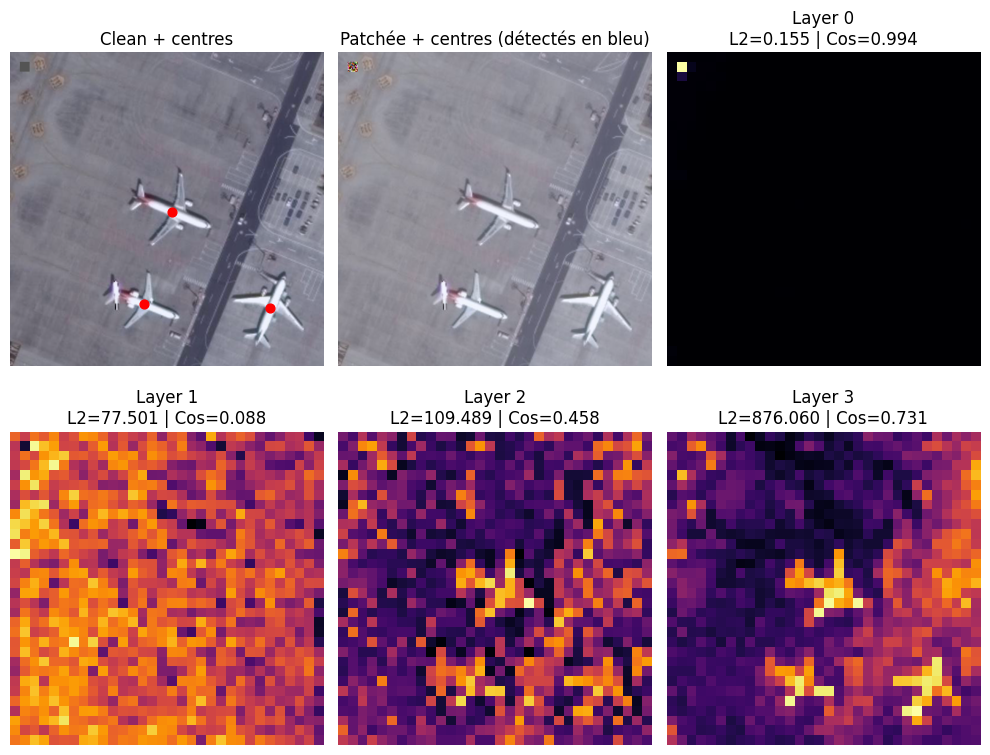

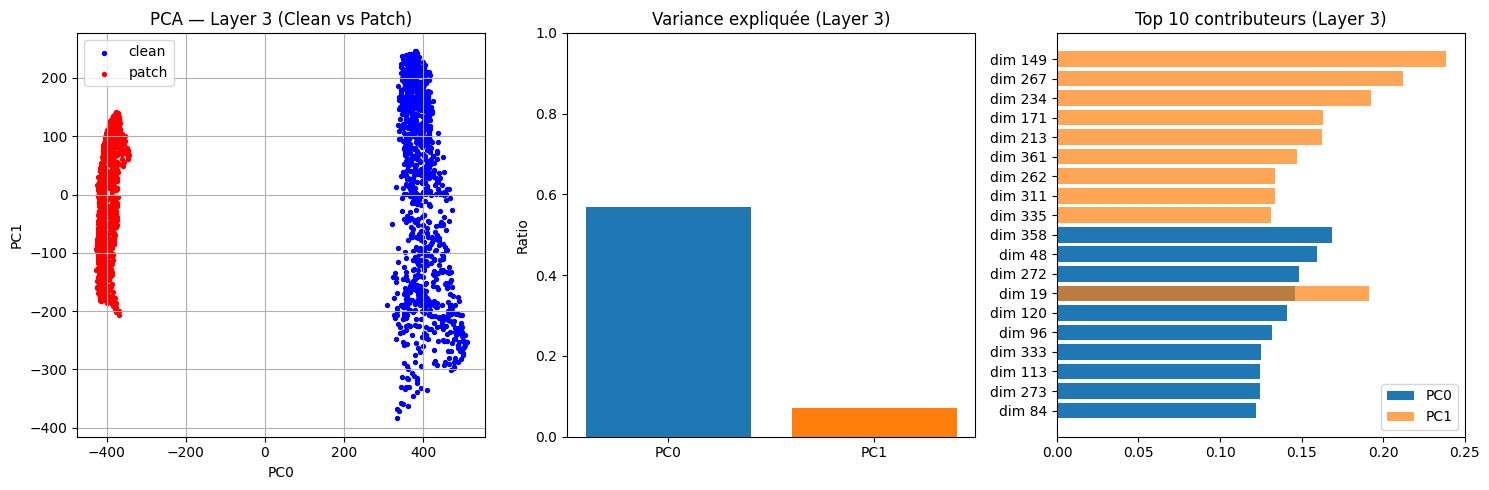

In [235]:
cfg2 = {
    "name": "patch16_divulse",
    "path": "attack_results/21_02-patch16_16_divulse-stern/patch.pt",
    "size": 16,
    "px": 16,
    "py": 16,
    "threshold": 0.3,
    "checkpoint": "runs/18_02-12_57_10_SMALL-PLUS_divulse-stern.pth",
    "image_id": "P2550_obj_6",
    "data_dir": "data/DOTA/DOTA_PLANES_TILED",
    "model_size": "small-plus",
    "device": "cuda",
    "return_embeddings": True
}
stats_16_1_img6, img, meta = visu_embeddings(cfg2)
stats = stats_16_1_img6
visualize_all_with_centers_no_save(
    img_clean = img,
    img_patch = stats["img_patch"],
    feats_clean = stats["feats_clean"],
    feats_patch = stats["feats_patch"],
    centers_clean = stats["pred_clean"],
    centers_patch = stats["pred_patched"],
    tile_id = cfg2["image_id"]
)
visualize_pca_layer3_with_contrib(
    stats["feats_clean"],
    stats["feats_patch"]
)

Patch 2 en position (16, 16)

Image shape: torch.Size([1, 3, 512, 512])


Loading weights:   0%|          | 0/235 [00:00<?, ?it/s]

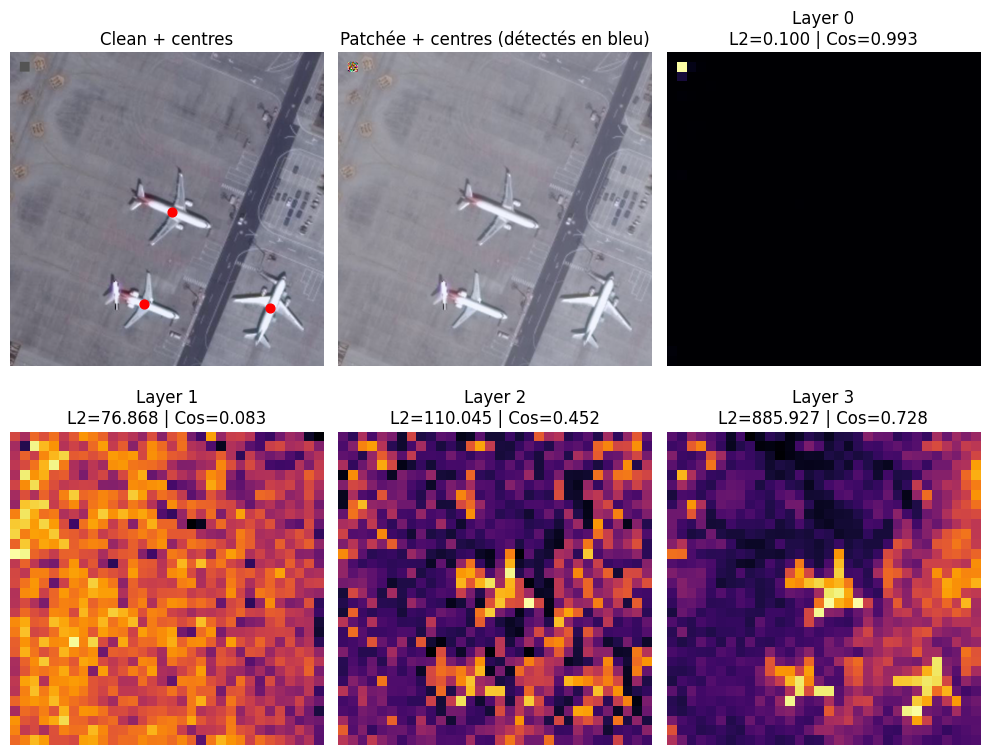

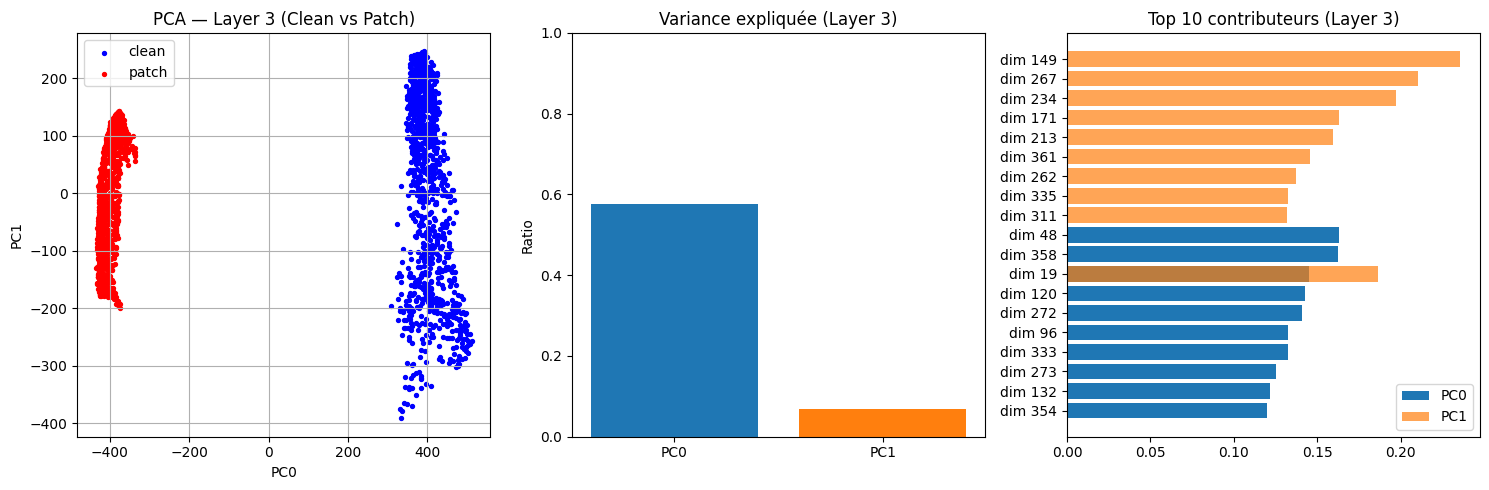

In [236]:
cfg2 = {
    "name": "patch16_divulse_2",
    "path": "attack_results/21_02-patch16_16_en16_divulse-stern/patch.pt",
    "size": 16,
    "px": 16,
    "py": 16,
    "threshold": 0.3,
    "checkpoint": "runs/18_02-12_57_10_SMALL-PLUS_divulse-stern.pth",
    "image_id": "P2550_obj_6",
    "data_dir": "data/DOTA/DOTA_PLANES_TILED",
    "model_size": "small-plus",
    "device": "cuda",
    "return_embeddings": True
}
stats_16_2_img6, img, meta = visu_embeddings(cfg2)
stats = stats_16_2_img6
visualize_all_with_centers_no_save(
    img_clean = img,
    img_patch = stats["img_patch"],
    feats_clean = stats["feats_clean"],
    feats_patch = stats["feats_patch"],
    centers_clean = stats["pred_clean"],
    centers_patch = stats["pred_patched"],
    tile_id = cfg2["image_id"]
)
visualize_pca_layer3_with_contrib(
    stats["feats_clean"],
    stats["feats_patch"]
)

Image shape: torch.Size([1, 3, 512, 512])


Loading weights:   0%|          | 0/235 [00:00<?, ?it/s]

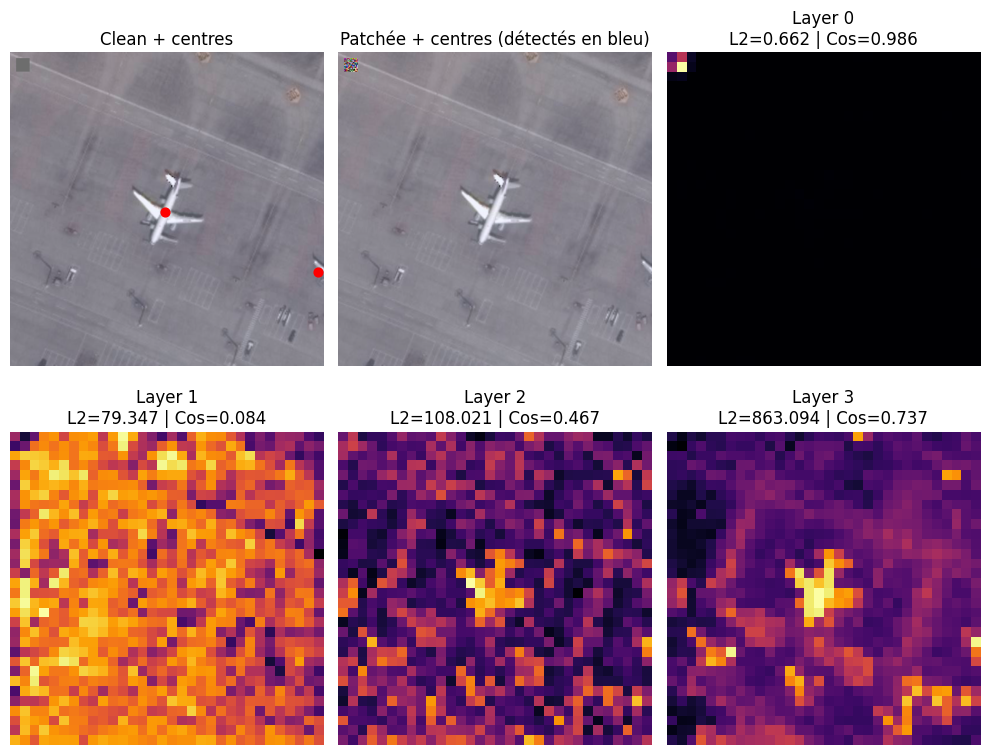

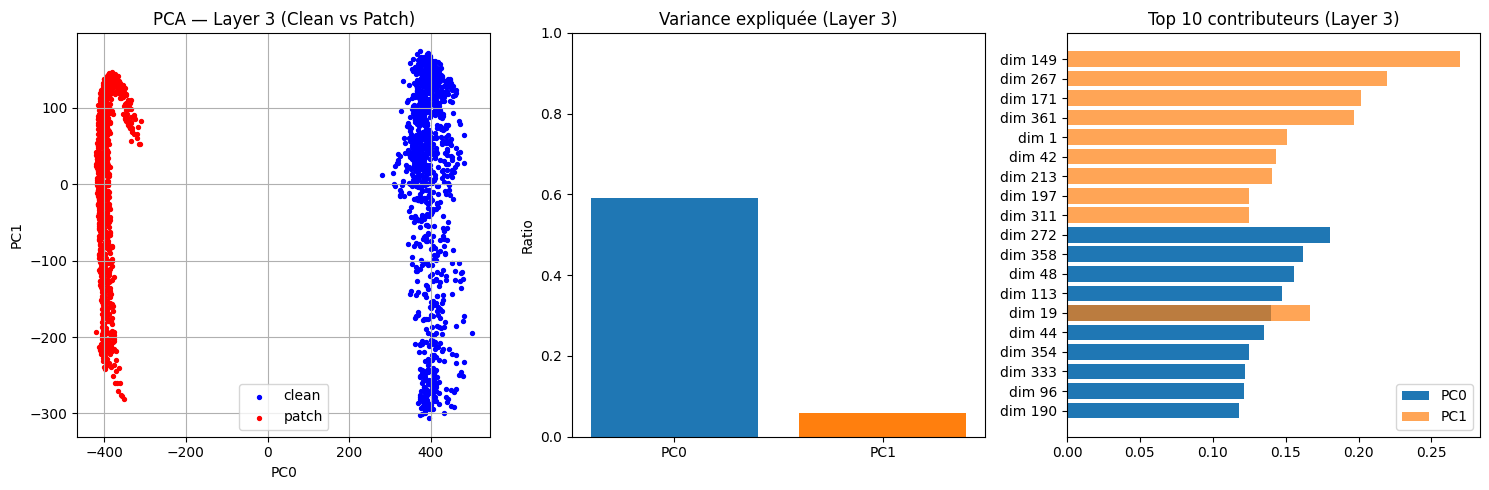

In [78]:
cfg2 = {
    "name": "patch22_divulse",
    "path": "attack_results/18_02-patch22_divulse-stern/patch.pt",
    "size": 22,
    "px": 10,
    "py": 10,
    "threshold": 0.3,
    "checkpoint": "runs/18_02-12_57_10_SMALL-PLUS_divulse-stern.pth",
    "image_id": "P2550_obj_17",
    "data_dir": "data/DOTA/DOTA_PLANES_TILED",
    "model_size": "small-plus",
    "device": "cuda",
    "return_embeddings": True
}
stats_22_img17, img, meta = visu_embeddings(cfg2)
stats = stats_22_img17
visualize_all_with_centers_no_save(
    img_clean = img,
    img_patch = stats["img_patch"],
    feats_clean = stats["feats_clean"],
    feats_patch = stats["feats_patch"],
    centers_clean = stats["pred_clean"],
    centers_patch = stats["pred_patched"],
    tile_id = cfg2["image_id"]
)
visualize_pca_layer3_with_contrib(
    stats["feats_clean"],
    stats["feats_patch"]
)


## Part III PCA entre patch et images

Nous avons vu les PCA entre l'image avec et sans patch dans le capitre précédent pour simplifier le notebook.

Maintenant, nous allons voir le comportement d'un patch sur deux images en terme de PCA.

In [237]:
def pca_two_views(
    clean_A, patch_A,
    clean_B, patch_B,
    label_A="imgA",
    label_B="imgB"
):
    # --- Conversion interne PyTorch → NumPy ---
    def to_np(x):
        if isinstance(x, torch.Tensor):
            x = x.detach().cpu().numpy()
        if x.ndim == 3:   # cas (1, 1024, C)
            x = x[0]
        return x

    clean_A = to_np(clean_A)
    patch_A = to_np(patch_A)
    clean_B = to_np(clean_B)
    patch_B = to_np(patch_B)

    D_A = patch_A - clean_A

    # --- PCA 1 : axes définis par clean A + patch A ---
    pca_A = PCA(n_components=2)
    pca_A.fit(D_A)

    proj_A_clean_A = pca_A.transform(clean_A)
    proj_A_patch_A = pca_A.transform(patch_A)
    proj_A_clean_B = pca_A.transform(clean_B)
    proj_A_patch_B = pca_A.transform(patch_B)

    # --- PCA 2 : axes définis par clean B + patch B ---
    D_B = patch_B - clean_B
    pca_B = PCA(n_components=2)
    pca_B.fit(D_B)

    proj_B_clean_A = pca_B.transform(clean_A)
    proj_B_patch_A = pca_B.transform(patch_A)
    proj_B_clean_B = pca_B.transform(clean_B)
    proj_B_patch_B = pca_B.transform(patch_B)

    # --- Figure ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # ---------------------------
    # 1) PCA définie par image A
    # ---------------------------
    ax = axes[0]
    ax.scatter(proj_A_clean_A[:,0], proj_A_clean_A[:,1], s=10, c='blue', label=f"{label_A} clean")
    ax.scatter(proj_A_patch_A[:,0], proj_A_patch_A[:,1], s=10, c='red', label=f"{label_A} patch")

    ax.scatter(proj_A_clean_B[:,0], proj_A_clean_B[:,1], s=10, c='green', label=f"{label_B} clean")
    ax.scatter(proj_A_patch_B[:,0], proj_A_patch_B[:,1], s=10, c='orange', label=f"{label_B} patch")

    ax.set_title(f"PCA — axes définis par {label_A}")
    ax.set_xlabel("PC0")
    ax.set_ylabel("PC1")
    ax.grid(True)
    ax.legend()

    # ---------------------------
    # 2) PCA définie par image B
    # ---------------------------
    ax = axes[1]
    ax.scatter(proj_B_clean_A[:,0], proj_B_clean_A[:,1], s=10, c='blue', label=f"{label_A} clean")
    ax.scatter(proj_B_patch_A[:,0], proj_B_patch_A[:,1], s=10, c='red', label=f"{label_A} patch")

    ax.scatter(proj_B_clean_B[:,0], proj_B_clean_B[:,1], s=10, c='green', label=f"{label_B} clean")
    ax.scatter(proj_B_patch_B[:,0], proj_B_patch_B[:,1], s=10, c='orange', label=f"{label_B} patch")

    ax.set_title(f"PCA — axes définis par {label_B}")
    ax.set_xlabel("PC0")
    ax.set_ylabel("PC1")
    ax.grid(True)
    ax.legend()

    plt.tight_layout()
    plt.show()

Les axes de projection des PCA sont donnés par la différence entre les embeddings de sortie de l'image patchée avec l'image non patchée

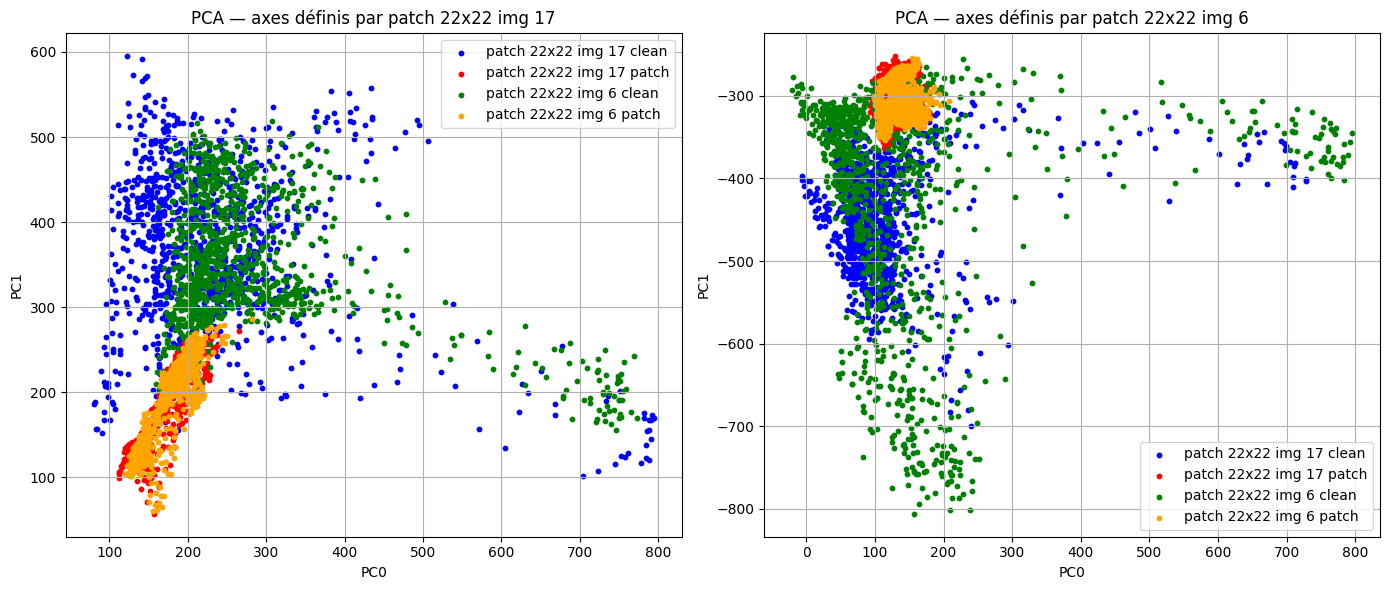

In [238]:
pca_two_views(
    clean_A = stats_22_img17["feats_clean"][3],
    patch_A = stats_22_img17["feats_patch"][3],
    clean_B = stats_22_img6["feats_clean"][3],
    patch_B = stats_22_img6["feats_patch"][3],
    label_A="patch 22x22 img 17",
    label_B="patch 22x22 img 6"
)


Les deux images patchées sont envoyées au même endroit

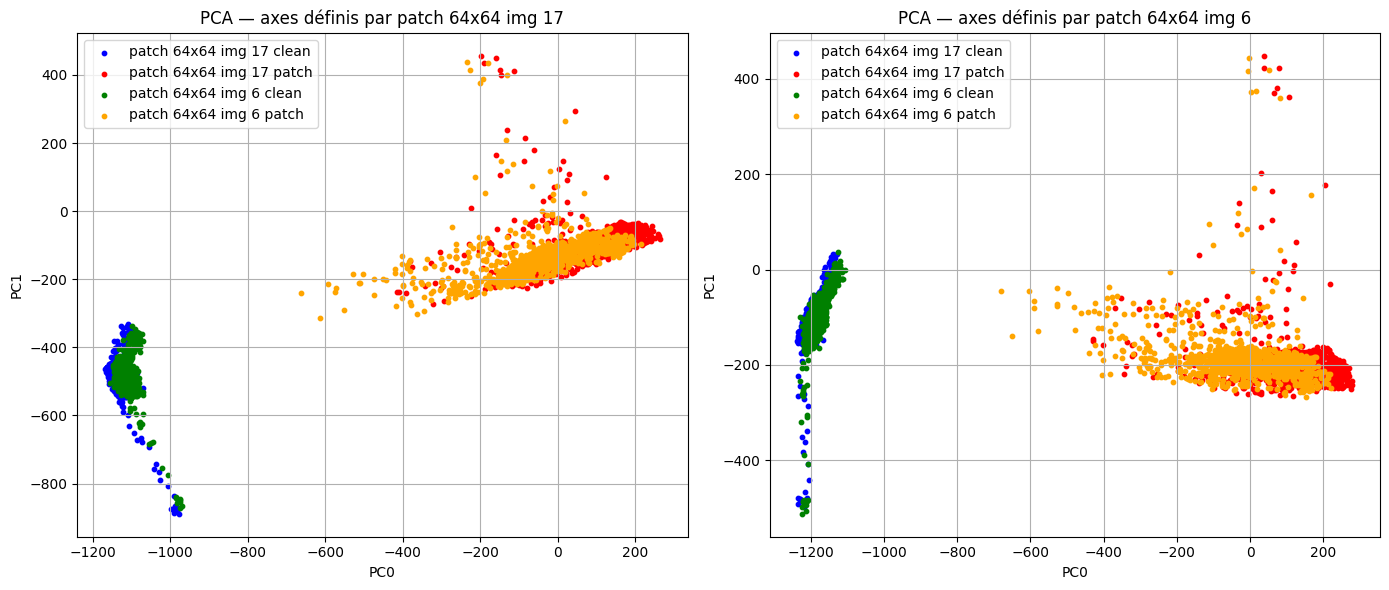

In [81]:
pca_two_views(
    clean_A = stats_64_img17["feats_clean"][3],
    patch_A = stats_64_img17["feats_patch"][3],
    clean_B = stats_64_img6["feats_clean"][3],
    patch_B = stats_64_img6["feats_patch"][3],
    label_A="patch 64x64 img 17",
    label_B="patch 64x64 img 6"
)


Pour le patch 64 x 64, nous voyons qu'il sépare beaucoup plus ses images par rapport au patch 22 x 22.

Cette représentation nous a apporté peu d'information.

Nous allons voir pour une même image comment le patch aurait séparé le patch comparé

In [239]:
def pca_two_patch(
    clean_A, patch_A,
    clean_B, patch_B,
    label_A="patch A",
    label_B="patch B"
):
    # --- Conversion interne PyTorch → NumPy ---
    def to_np(x):
        if isinstance(x, torch.Tensor):
            x = x.detach().cpu().numpy()
        if x.ndim == 3:   # cas (1, 1024, C)
            x = x[0]
        return x

    clean_A = to_np(clean_A)
    patch_A = to_np(patch_A)
    clean_B = to_np(clean_B)
    patch_B = to_np(patch_B)
    D_A = patch_A - clean_A
    # --- PCA 1 : axes définis par clean A + patch A ---
    pca_A = PCA(n_components=2)
    pca_A.fit(D_A)# , axis=0)

    proj_A_clean_A = pca_A.transform(clean_A)
    proj_A_patch_A = pca_A.transform(patch_A)
    proj_A_clean_B = pca_A.transform(clean_B)
    proj_A_patch_B = pca_A.transform(patch_B)

    # --- PCA 2 : axes définis par clean B + patch B ---
    D_B = patch_B - clean_B
    pca_B = PCA(n_components=2)
    pca_B.fit(D_B)

    proj_B_clean_A = pca_B.transform(clean_A)
    proj_B_patch_A = pca_B.transform(patch_A)
    proj_B_clean_B = pca_B.transform(clean_B)
    proj_B_patch_B = pca_B.transform(patch_B)

    # --- Figure ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # ---------------------------
    # 1) PCA définie par image A
    # ---------------------------
    ax = axes[0]
    ax.scatter(proj_A_clean_A[:,0], proj_A_clean_A[:,1], s=10, c='blue', label=f"image non patchée")
    ax.scatter(proj_A_patch_A[:,0], proj_A_patch_A[:,1], s=10, c='red', label=f"{label_A}")

    # ax.scatter(proj_A_clean_B[:,0], proj_A_clean_B[:,1], s=10, c='green', label=f"{label_B} clean")
    ax.scatter(proj_A_patch_B[:,0], proj_A_patch_B[:,1], s=10, c='orange', label=f"{label_B}")

    ax.set_title(f"PCA — axes définis par {label_A}")
    ax.set_xlabel("PC0")
    ax.set_ylabel("PC1")
    ax.grid(True)
    ax.legend()

    # ---------------------------
    # 2) PCA définie par image B
    # ---------------------------
    ax = axes[1]
    ax.scatter(proj_B_clean_A[:,0], proj_B_clean_A[:,1], s=10, c='blue', label=f"image non patchée")
    ax.scatter(proj_B_patch_A[:,0], proj_B_patch_A[:,1], s=10, c='red', label=f"{label_A}")

    # ax.scatter(proj_B_clean_B[:,0], proj_B_clean_B[:,1], s=10, c='green', label=f"{label_B} clean")
    ax.scatter(proj_B_patch_B[:,0], proj_B_patch_B[:,1], s=10, c='orange', label=f"{label_B}")

    ax.set_title(f"PCA — axes définis par {label_B}")
    ax.set_xlabel("PC0")
    ax.set_ylabel("PC1")
    ax.grid(True)
    ax.legend()

    plt.tight_layout()
    plt.show()

Les axes de projection des PCA sont donnés par la différence entre les embeddings de sortie de l'image patchée avec l'image non patchée

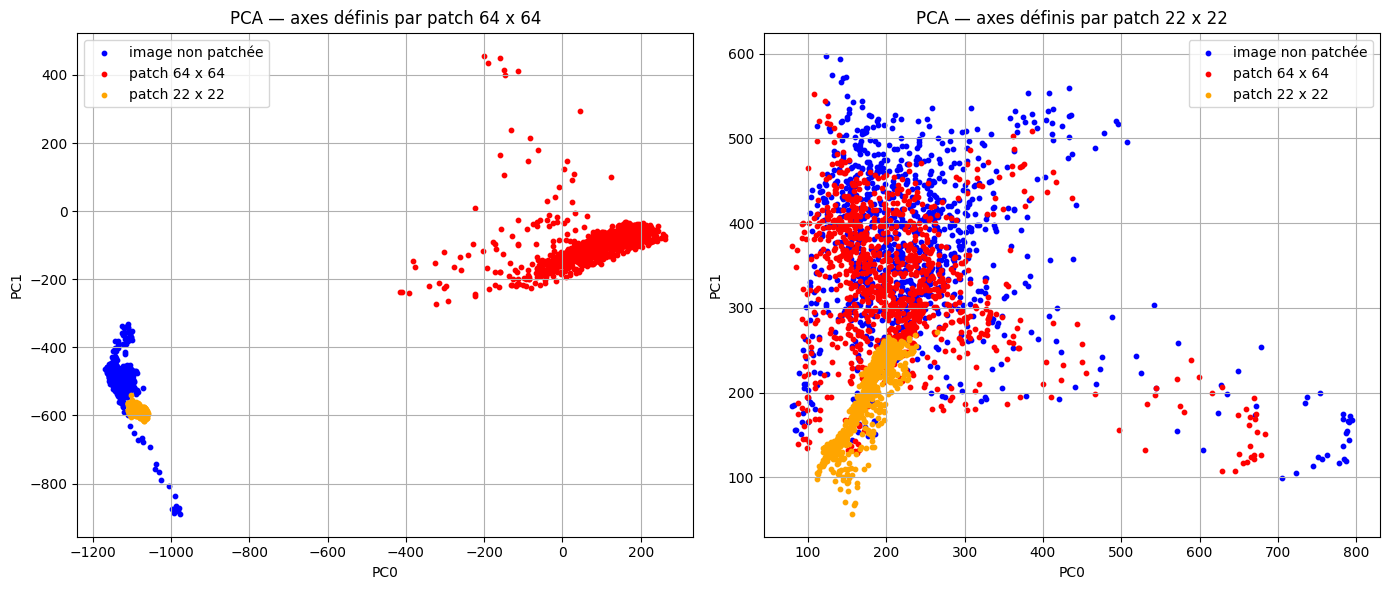

In [240]:
pca_two_patch(
    clean_A = stats_64_img17["feats_clean"][3],
    patch_A = stats_64_img17["feats_patch"][3],
    clean_B = stats_22_img17["feats_clean"][3],
    patch_B = stats_22_img17["feats_patch"][3],
    label_A="patch 64 x 64",
    label_B="patch 22 x 22"
)

Pour l'image 17.

Nous voyons que chaque patch sous estime son conccurrent. Et que le patch 64 x 64 sépare le plus.

Mais cela nous a donné l'idée de faire un petit patch en l'apprenant pour qu'il se place au même endroit que le patch 64 x 64. 

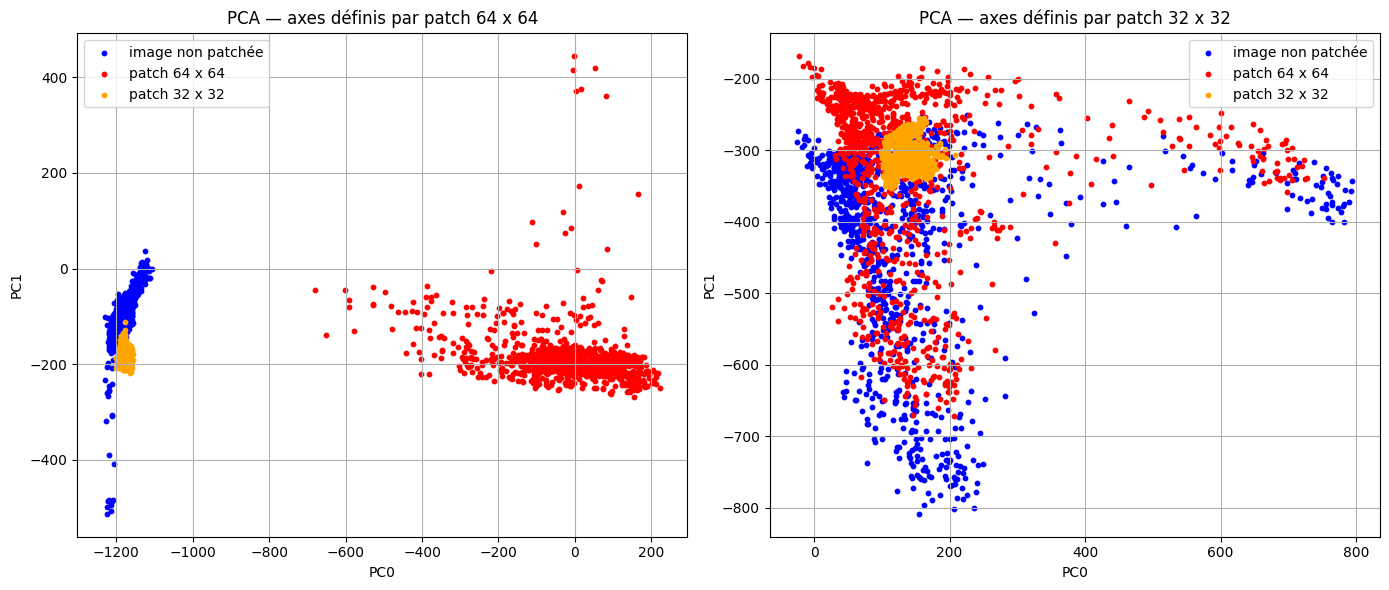

In [84]:
pca_two_patch(
    clean_A = stats_64_img6["feats_clean"][3],
    patch_A = stats_64_img6["feats_patch"][3],
    clean_B = stats_22_img6["feats_clean"][3],
    patch_B = stats_22_img6["feats_patch"][3],
    label_A="patch 64 x 64",
    label_B="patch 32 x 32"
)

Pour l'image 6, nous faisons le même constat

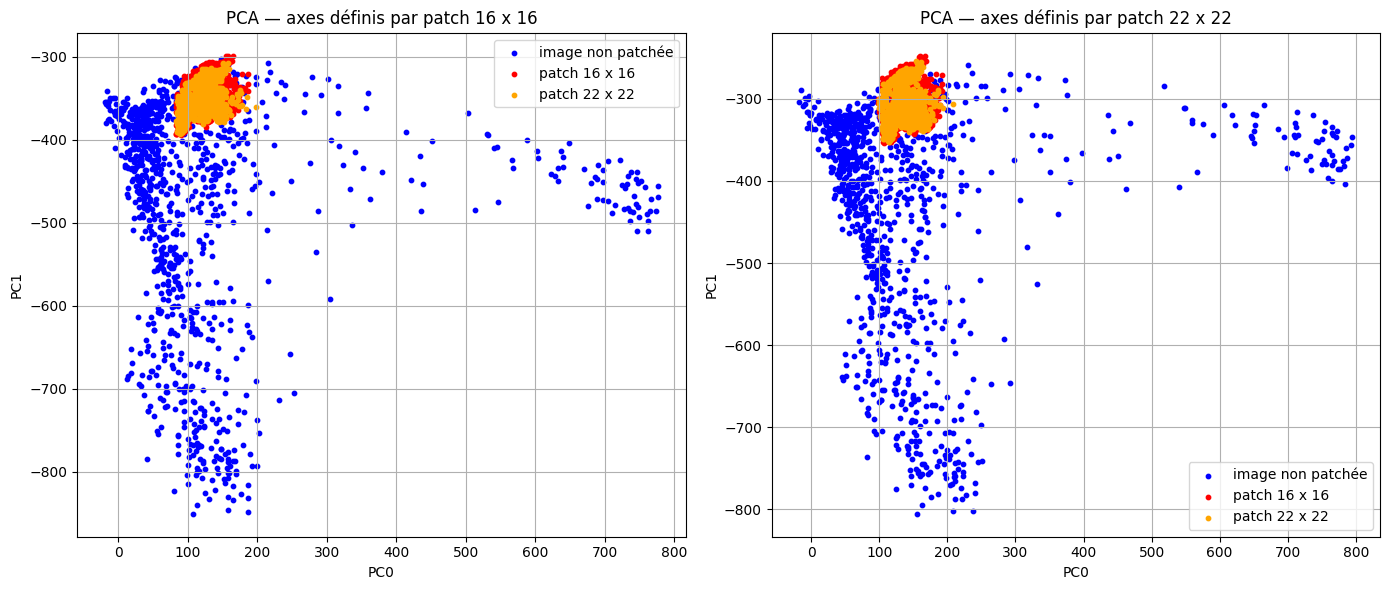

In [85]:
pca_two_patch(
    clean_A = stats_16_1_img6["feats_clean"][3],
    patch_A = stats_16_1_img6["feats_patch"][3],
    clean_B = stats_22_img6["feats_clean"][3],
    patch_B = stats_22_img6["feats_patch"][3],
    label_A="patch 16 x 16",
    label_B="patch 22 x 22"
)

Les patch 16x16 et 22x22, se placent au même endroit

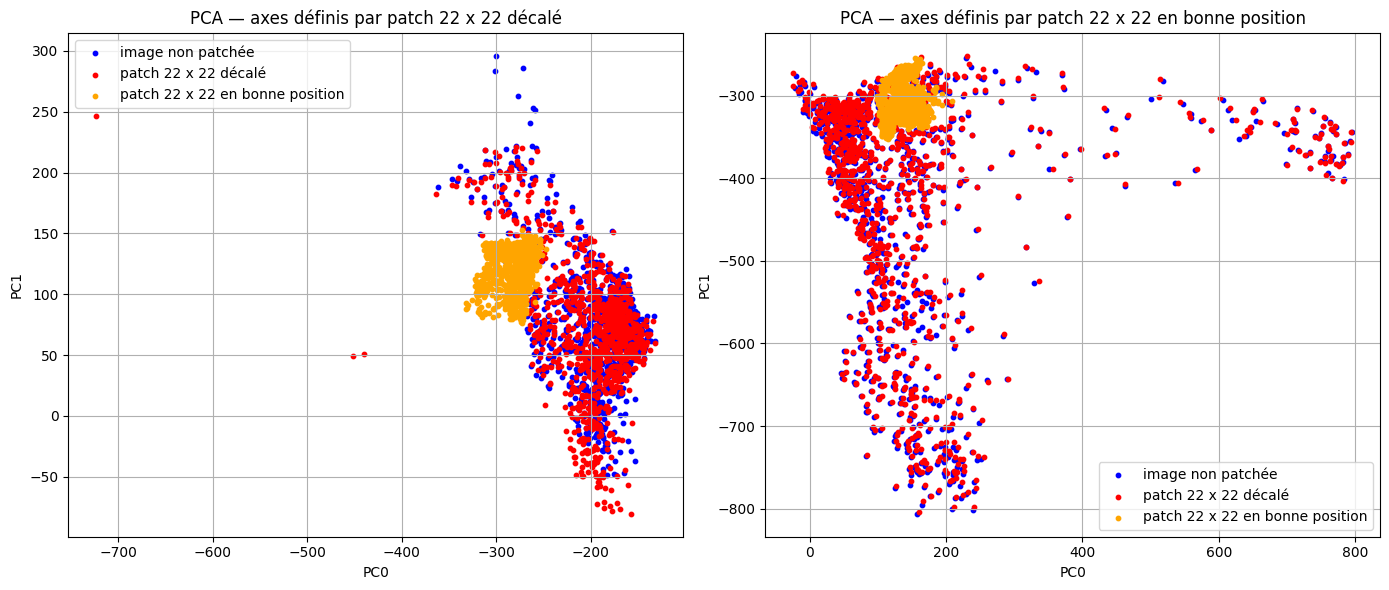

In [86]:
pca_two_patch(
    clean_A = stats_22_pos11_img6["feats_clean"][3],
    patch_A = stats_22_pos11_img6["feats_patch"][3],
    clean_B = stats_22_img6["feats_clean"][3],
    patch_B = stats_22_img6["feats_patch"][3],
    label_A="patch 22 x 22 décalé",
    label_B="patch 22 x 22 en bonne position"
)


Nous observons que des petits patch décalent bien seulement si ils sont dans la bonne position d'apprentissage.

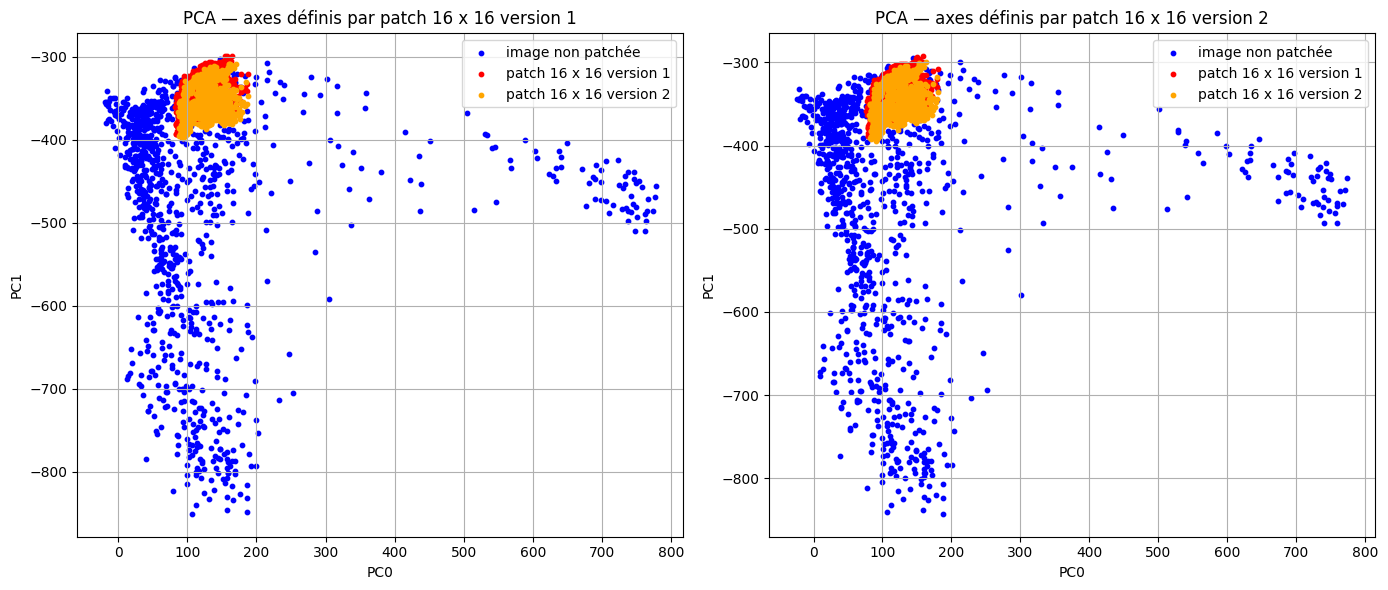

In [87]:
pca_two_patch(
    clean_A = stats_16_1_img6["feats_clean"][3],
    patch_A = stats_16_1_img6["feats_patch"][3],
    clean_B = stats_16_2_img6["feats_clean"][3],
    patch_B = stats_16_2_img6["feats_patch"][3],
    label_A="patch 16 x 16 version 1",
    label_B="patch 16 x 16 version 2"
)


Les deux patch se ressemblent beaucoup.

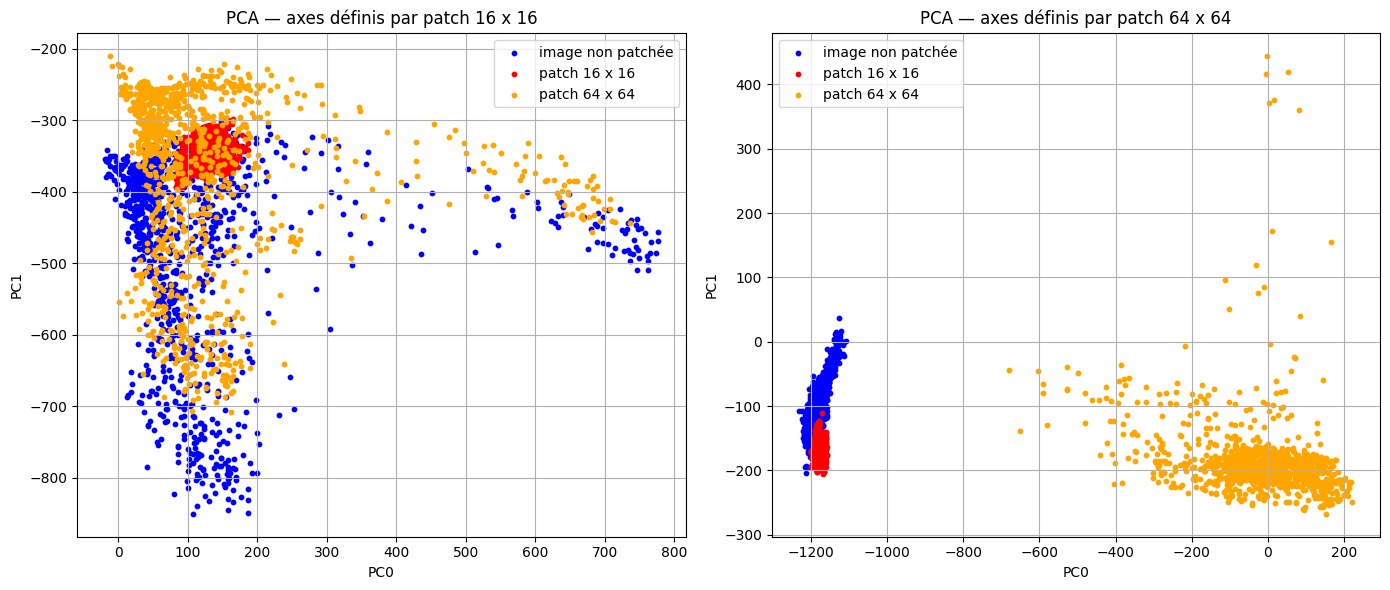

In [88]:
pca_two_patch(
    clean_A = stats_16_1_img6["feats_clean"][3],
    patch_A = stats_16_1_img6["feats_patch"][3],
    clean_B = stats_64_img6["feats_clean"][3],
    patch_B = stats_64_img6["feats_patch"][3],
    label_A="patch 16 x 16",
    label_B="patch 64 x 64"
)


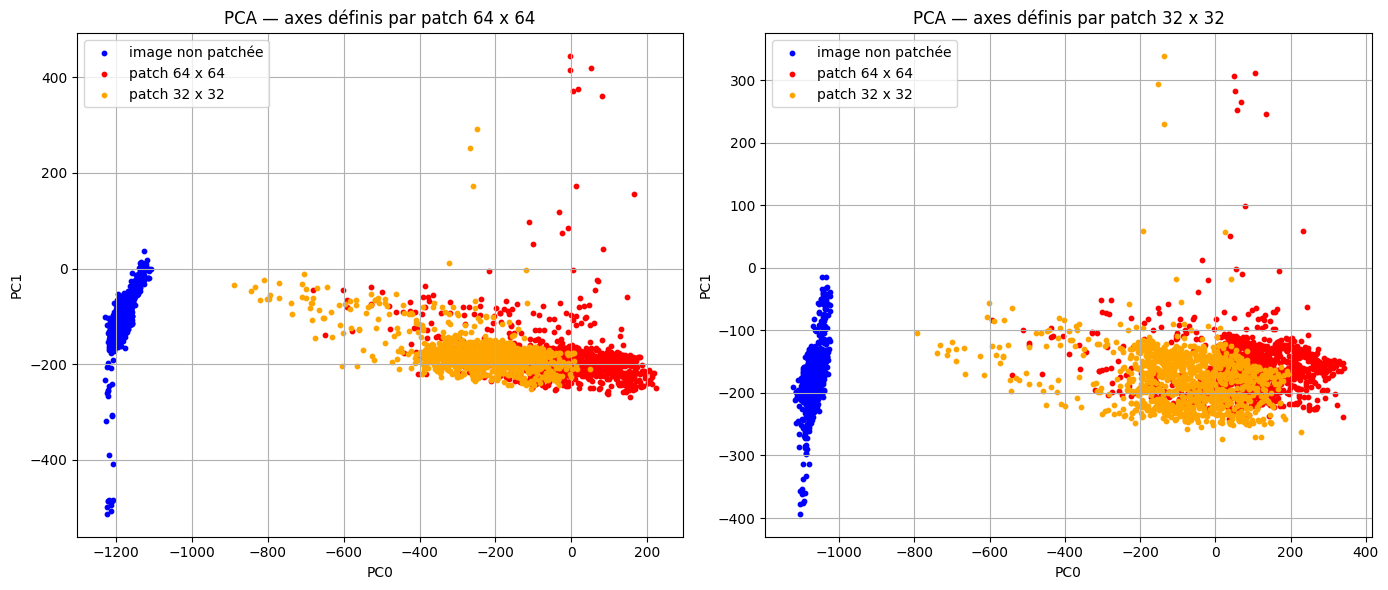

In [89]:
pca_two_patch(
    clean_A = stats_64_img6["feats_clean"][3],
    patch_A = stats_64_img6["feats_patch"][3],
    clean_B = stats_32_img6["feats_clean"][3],
    patch_B = stats_32_img6["feats_patch"][3],
    label_A="patch 64 x 64",
    label_B="patch 32 x 32"
)

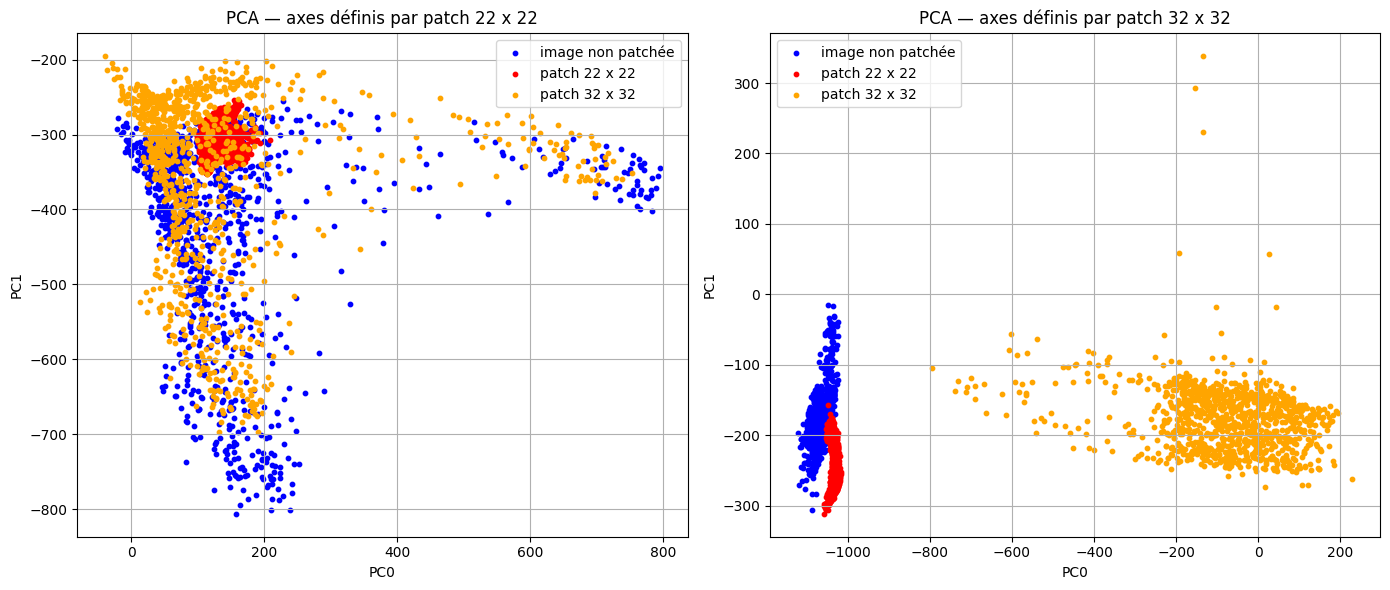

In [90]:
pca_two_patch(
    clean_A = stats_22_img6["feats_clean"][3],
    patch_A = stats_22_img6["feats_patch"][3],
    clean_B = stats_32_img6["feats_clean"][3],
    patch_B = stats_32_img6["feats_patch"][3],
    label_A="patch 22 x 22",
    label_B="patch 32 x 32"
)

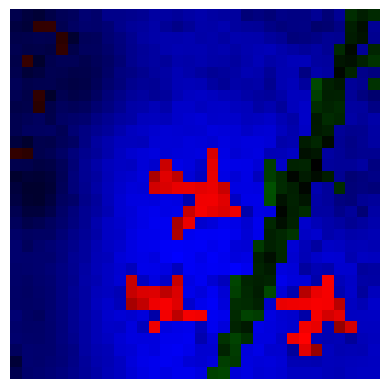

In [241]:
clean_A = stats_22_img6["feats_clean"][3][0]
patch_A = stats_22_img6["feats_patch"][3][0]

clean_A = clean_A.detach().cpu().numpy()
patch_A = patch_A.detach().cpu().numpy()

N, C = clean_A.shape   # N=1024, C=384
H = W = int(np.sqrt(N))  # 32

clean_2d = clean_A.T.reshape(C, H, W)
patch_2d = patch_A.T.reshape(C, H, W)

D = patch_2d - clean_2d   # (C, H, W)

diff_flat = D.reshape(C, -1).T  # (H*W, C)

pca = PCA(n_components=3)
proj = pca.fit_transform(diff_flat)

proj_norm = (proj - proj.min(0)) / (proj.max(0) - proj.min(0) + 1e-8)

# pca_img = proj_norm.reshape(H, W, 3)
dominant_axis = np.argmax(np.abs(proj_norm), axis=1)   # (H*W,)

# --- 7. Construction de l'image RGB à 3 couleurs ---
pca_img = np.zeros((H*W, 3))

# Rouge pour PC1
pca_img[dominant_axis == 0] = [0, 0, 1] * (1-proj_norm[dominant_axis == 0])

# Vert pour PC2
pca_img[dominant_axis == 1] = [0, 1, 0] * (1-proj_norm[dominant_axis == 1])

# Bleu pour PC3
pca_img[dominant_axis == 2] = [1, 0, 0] * (1-proj_norm[dominant_axis > 1])

# Reshape final
pca_img = pca_img.reshape(H, W, 3)

plt.imshow(pca_img)
plt.axis("off")
plt.show()


## Patch 32 x 32 Distilled

Patch 32 x 32 appris avec la précedente méthode. Le patch est positionné aléatoirement à chaque image

In [102]:
cfg = {
        "name": "patch32_divulse old method",
        "path": "attack_results/28_02-11_20_43_divulse-stern/patch.pt",
        "size": 32,
        "px": 10,
        "py": 10,
        "threshold": 0.3,
        "checkpoint": "runs/18_02-12_57_10_SMALL-PLUS_divulse-stern.pth"
    }

attack(cfg)


=== Evaluating patch32_divulse old method ===


Loading weights:   0%|          | 0/235 [00:00<?, ?it/s]

eval: 100%|██████████| 147/147 [00:38<00:00,  3.80it/s]

Image     |   GT | clean | patched | recall clean → patched
------------------------------------------------------------
P2269     |    3 |     3 |       3 |   1.00 → 1.00
P2288     |  206 |   153 |     144 |   0.74 → 0.70
P2523     |   16 |    16 |      16 |   1.00 → 1.00
P2550     |   67 |    61 |      61 |   0.91 → 0.91
P2551     |  321 |   277 |     271 |   0.86 → 0.84
P2552     |  215 |   200 |     197 |   0.93 → 0.92
P2553     |  161 |   143 |     140 |   0.89 → 0.87
P2554     |  215 |   203 |     201 |   0.94 → 0.93
P2557     |   63 |    58 |      59 |   0.92 → 0.94
P2558     |  391 |   385 |     383 |   0.98 → 0.98
P2560     |  288 |   270 |     269 |   0.94 → 0.93
P2600     |   45 |    44 |      43 |   0.98 → 0.96
P2665     |    6 |     6 |       6 |   1.00 → 1.00
P2682     |   28 |    24 |      23 |   0.86 → 0.82
P2691     |  392 |   358 |     353 |   0.91 → 0.90
P2741     |    1 |     0 |       0 |   0.00 → 0.00
P2746     |   18 |    16 |      16 |   0.89 → 0.89
P2748     | 

Patch 32x32 appris par distillation vers le patch 64x64 près 40 epochs (lr = 0.01 et lambda pour cos_similarity = 0.1)

In [103]:
cfg = {
        "name": "patch32_divulse 1",
        "path": "attack_results/27_02-19_56_47_divulse-stern/patch32_distilled.pt",
        "size": 32,
        "px": 10,
        "py": 10,
        "threshold": 0.3,
        "checkpoint": "runs/18_02-12_57_10_SMALL-PLUS_divulse-stern.pth"
    }

attack(cfg)


=== Evaluating patch32_divulse 1 ===


Loading weights:   0%|          | 0/235 [00:00<?, ?it/s]

eval: 100%|██████████| 147/147 [00:41<00:00,  3.58it/s]

Image     |   GT | clean | patched | recall clean → patched
------------------------------------------------------------
P2269     |    3 |     3 |       0 |   1.00 → 0.00
P2288     |  206 |   153 |      99 |   0.74 → 0.48
P2523     |   16 |    16 |      16 |   1.00 → 1.00
P2550     |   67 |    61 |       6 |   0.91 → 0.09
P2551     |  321 |   277 |     105 |   0.86 → 0.33
P2552     |  215 |   200 |     115 |   0.93 → 0.53
P2553     |  161 |   143 |      53 |   0.89 → 0.33
P2554     |  215 |   203 |     122 |   0.94 → 0.57
P2557     |   63 |    58 |      27 |   0.92 → 0.43
P2558     |  391 |   385 |     105 |   0.98 → 0.27
P2560     |  288 |   270 |     130 |   0.94 → 0.45
P2600     |   45 |    44 |      41 |   0.98 → 0.91
P2665     |    6 |     6 |       2 |   1.00 → 0.33
P2682     |   28 |    24 |      18 |   0.86 → 0.64
P2691     |  392 |   358 |      80 |   0.91 → 0.20
P2741     |    1 |     0 |       0 |   0.00 → 0.00
P2746     |   18 |    16 |       3 |   0.89 → 0.17
P2748     | 

Image shape: torch.Size([1, 3, 512, 512])


Loading weights:   0%|          | 0/235 [00:00<?, ?it/s]

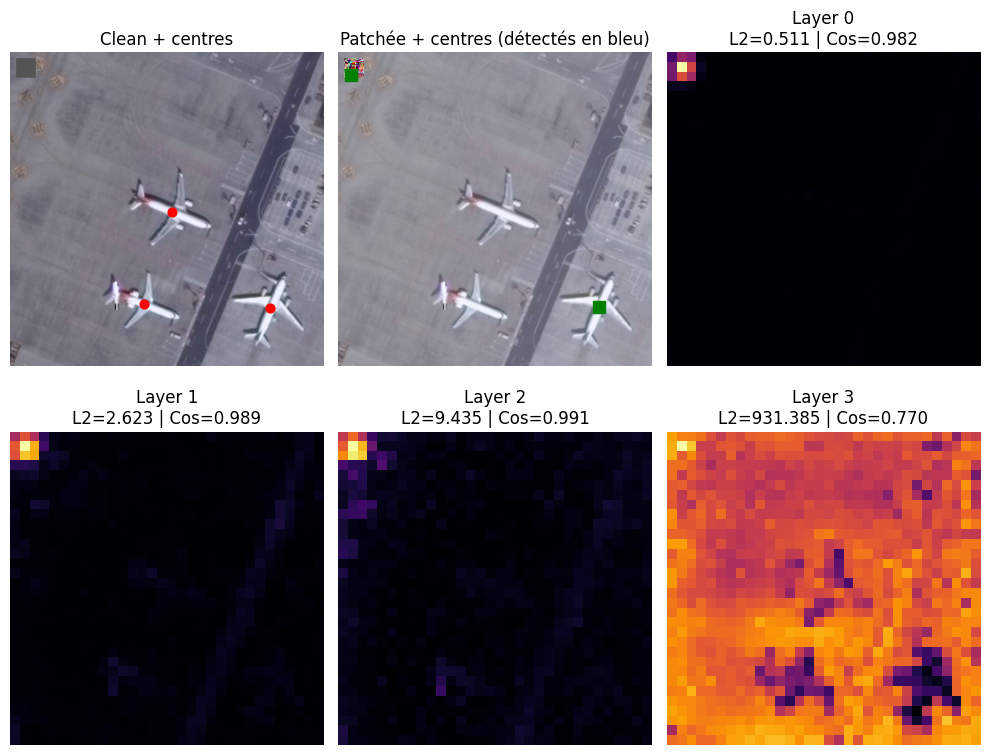

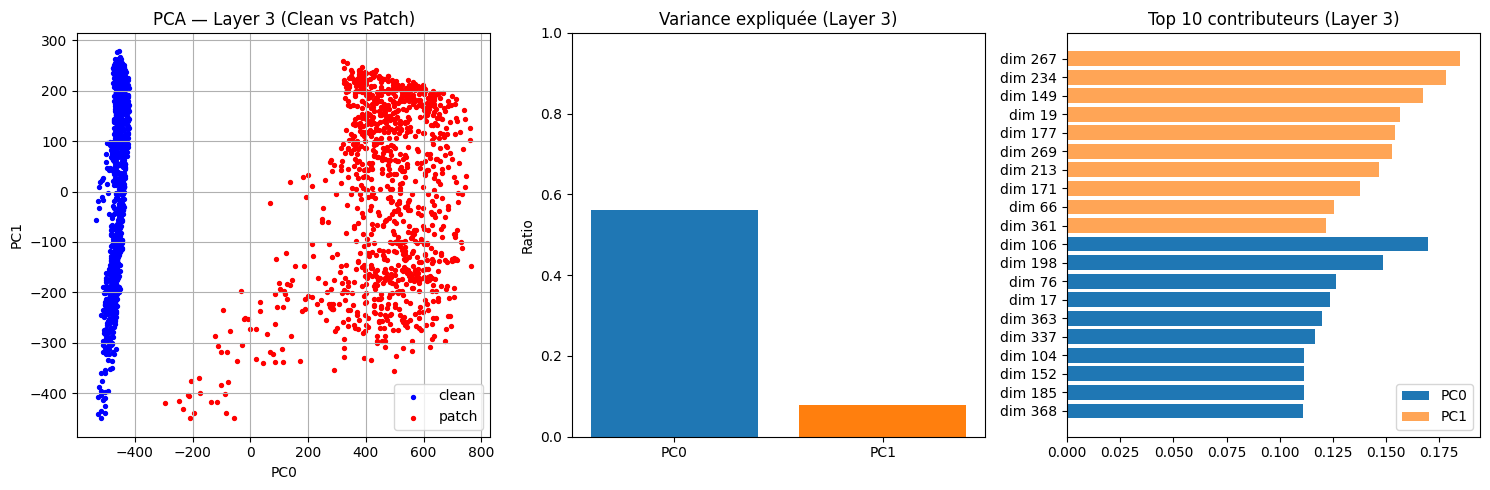

In [ ]:
cfg2 = {
    "name": "patch32_divulse_1",
    "path": "attack_results/27_02-19_56_47_divulse-stern/patch32_distilled.pt",
    "size": 32,
    "px": 10,
    "py": 10,
    "threshold": 0.3,
    "checkpoint": "runs/18_02-12_57_10_SMALL-PLUS_divulse-stern.pth",
    "image_id": "P2550_obj_6",
    "data_dir": "data/DOTA/DOTA_PLANES_TILED",
    "model_size": "small-plus",
    "device": "cuda",
    "return_embeddings": True
}
stats_32_1_img6, img, meta = visu_embeddings(cfg2)
stats = stats_32_1_img6
visualize_all_with_centers_no_save(
    img_clean = img,
    img_patch = stats["img_patch"],
    feats_clean = stats["feats_clean"],
    feats_patch = stats["feats_patch"],
    centers_clean = stats["pred_clean"],
    centers_patch = stats["pred_patched"],
    tile_id = cfg2["image_id"]
)
visualize_pca_layer3_with_contrib(
    stats["feats_clean"],
    stats["feats_patch"]
)


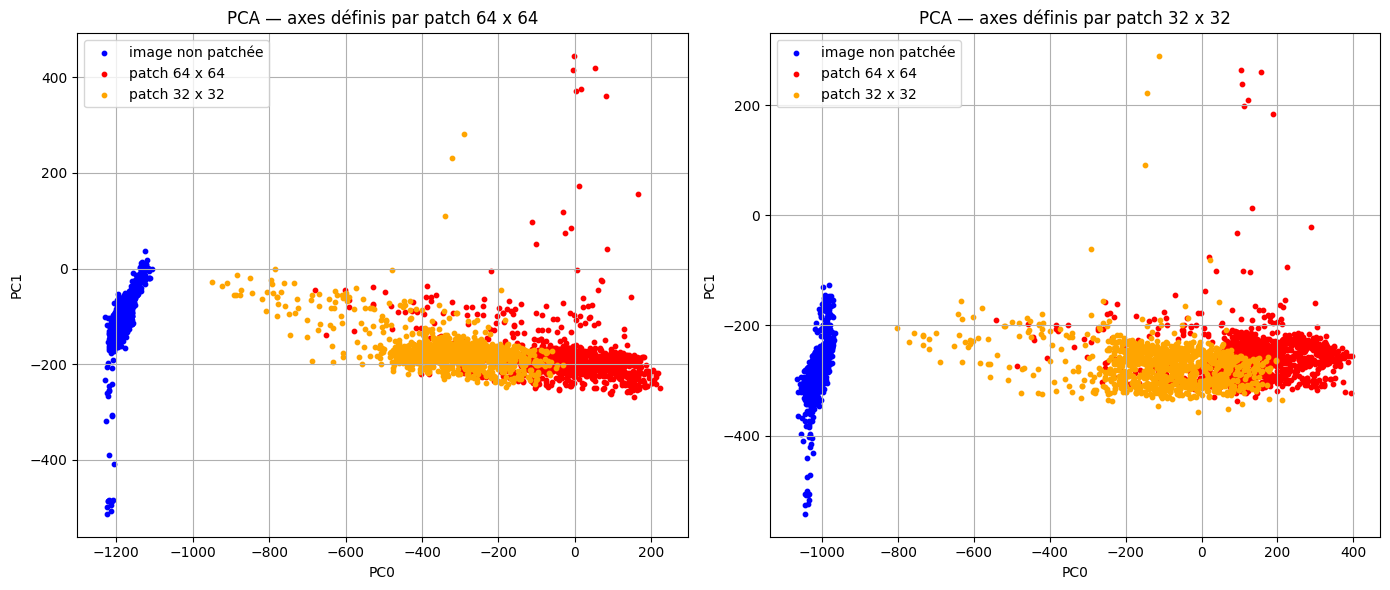

In [104]:
pca_two_patch(
    clean_A = stats_64_img6["feats_clean"][3],
    patch_A = stats_64_img6["feats_patch"][3],
    clean_B = stats_32_1_img6["feats_clean"][3],
    patch_B = stats_32_1_img6["feats_patch"][3],
    label_A="patch 64 x 64",
    label_B="patch 32 x 32"
)

Après 140 epochs (lr = 0.01 et lambda pour cos_similarity = 0.1)

In [105]:
cfg = {
        "name": "patch32_divulse_2",
        "path": "attack_results/27_02-21_06_39_divulse-stern/patch32_distilled.pt",
        "size": 32,
        "px": 10,
        "py": 10,
        "threshold": 0.3,
        "checkpoint": "runs/18_02-12_57_10_SMALL-PLUS_divulse-stern.pth"
    }

attack(cfg)


=== Evaluating patch32_divulse_2 ===


Loading weights:   0%|          | 0/235 [00:00<?, ?it/s]

eval: 100%|██████████| 147/147 [00:38<00:00,  3.79it/s]

Image     |   GT | clean | patched | recall clean → patched
------------------------------------------------------------
P2269     |    3 |     3 |       0 |   1.00 → 0.00
P2288     |  206 |   153 |      99 |   0.74 → 0.48
P2523     |   16 |    16 |      16 |   1.00 → 1.00
P2550     |   67 |    61 |       5 |   0.91 → 0.07
P2551     |  321 |   277 |     111 |   0.86 → 0.35
P2552     |  215 |   200 |     111 |   0.93 → 0.52
P2553     |  161 |   143 |      60 |   0.89 → 0.37
P2554     |  215 |   203 |     131 |   0.94 → 0.61
P2557     |   63 |    58 |      24 |   0.92 → 0.38
P2558     |  391 |   385 |     104 |   0.98 → 0.27
P2560     |  288 |   270 |     150 |   0.94 → 0.52
P2600     |   45 |    44 |      41 |   0.98 → 0.91
P2665     |    6 |     6 |       2 |   1.00 → 0.33
P2682     |   28 |    24 |      18 |   0.86 → 0.64
P2691     |  392 |   358 |      80 |   0.91 → 0.20
P2741     |    1 |     0 |       0 |   0.00 → 0.00
P2746     |   18 |    16 |       3 |   0.89 → 0.17
P2748     | 

Image shape: torch.Size([1, 3, 512, 512])


Loading weights:   0%|          | 0/235 [00:00<?, ?it/s]

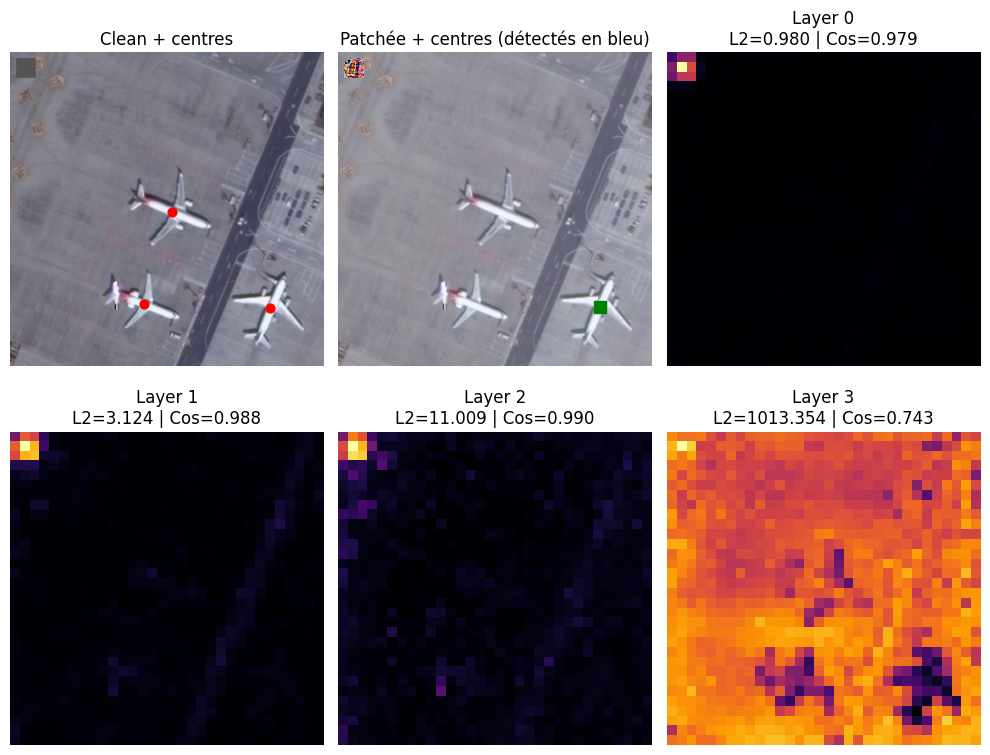

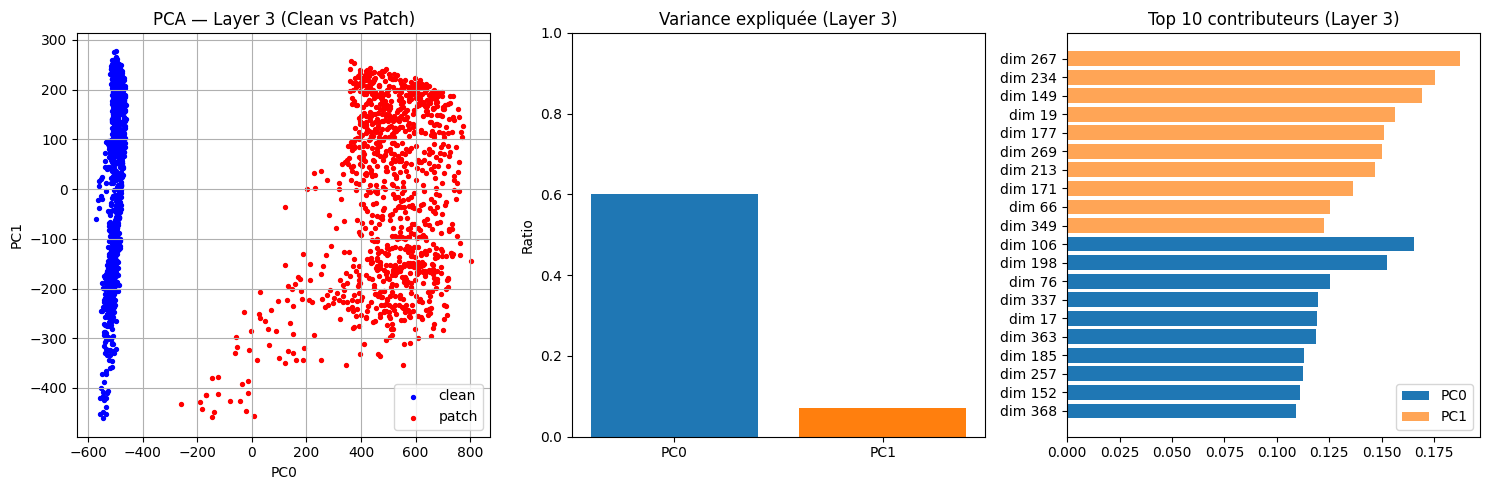

In [ ]:
cfg2 = {
    "name": "patch32_divulse_2",
    "path": "attack_results/27_02-21_06_39_divulse-stern/patch32_distilled.pt",
    "size": 32,
    "px": 10,
    "py": 10,
    "threshold": 0.3,
    "checkpoint": "runs/18_02-12_57_10_SMALL-PLUS_divulse-stern.pth",
    "image_id": "P2550_obj_6",
    "data_dir": "data/DOTA/DOTA_PLANES_TILED",
    "model_size": "small-plus",
    "device": "cuda",
    "return_embeddings": True
}
stats_32_2_img6, img, meta = visu_embeddings(cfg2)
stats = stats_32_2_img6
visualize_all_with_centers_no_save(
    img_clean = img,
    img_patch = stats["img_patch"],
    feats_clean = stats["feats_clean"],
    feats_patch = stats["feats_patch"],
    centers_clean = stats["pred_clean"],
    centers_patch = stats["pred_patched"],
    tile_id = cfg2["image_id"]
)
visualize_pca_layer3_with_contrib(
    stats["feats_clean"],
    stats["feats_patch"]
)


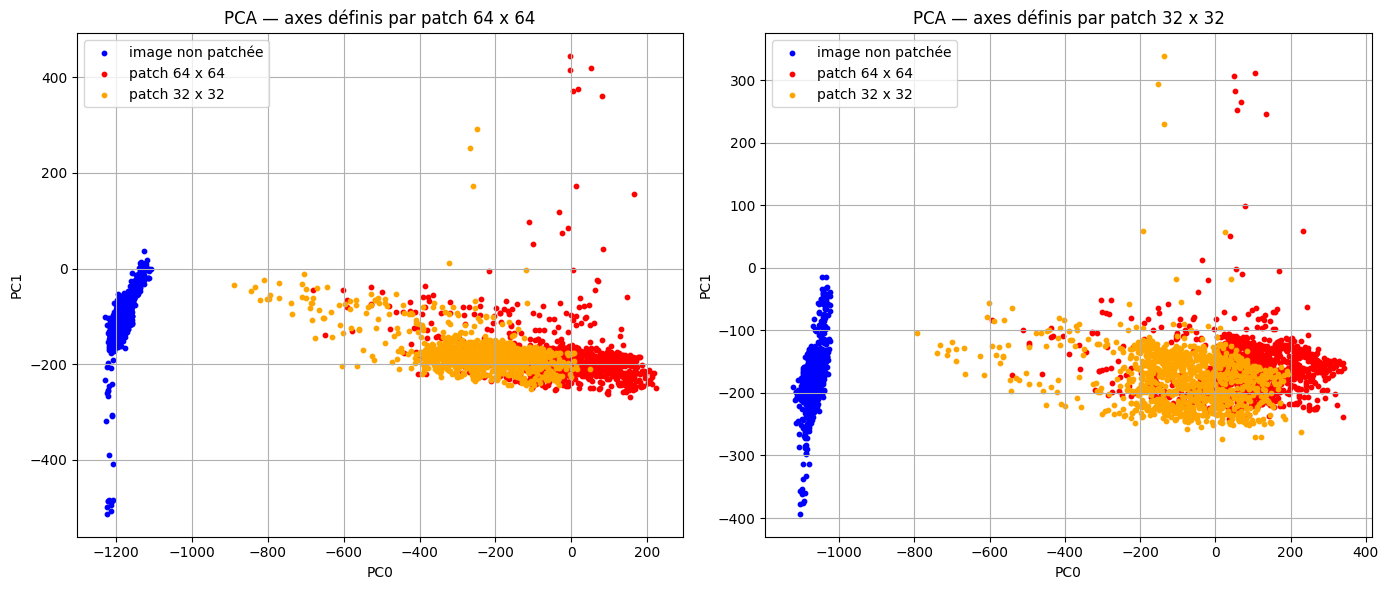

In [106]:
pca_two_patch(
    clean_A = stats_64_img6["feats_clean"][3],
    patch_A = stats_64_img6["feats_patch"][3],
    clean_B = stats_32_2_img6["feats_clean"][3],
    patch_B = stats_32_2_img6["feats_patch"][3],
    label_A="patch 64 x 64",
    label_B="patch 32 x 32"
)

Après 440 epochs (lr = 0.01 et lambda pour cos_similarity = 0.3 pour les 300 dernières)

In [107]:
cfg = {
        "name": "patch32_divulse_3",
        "path": "attack_results/27_02-23_21_24_divulse-stern/patch32_distilled.pt",
        "size": 32,
        "px": 10,
        "py": 10,
        "threshold": 0.3,
        "checkpoint": "runs/18_02-12_57_10_SMALL-PLUS_divulse-stern.pth"
    }

attack(cfg)


=== Evaluating patch32_divulse_3 ===


Loading weights:   0%|          | 0/235 [00:00<?, ?it/s]

eval: 100%|██████████| 147/147 [00:38<00:00,  3.81it/s]

Image     |   GT | clean | patched | recall clean → patched
------------------------------------------------------------
P2269     |    3 |     3 |       0 |   1.00 → 0.00
P2288     |  206 |   153 |     116 |   0.74 → 0.56
P2523     |   16 |    16 |      16 |   1.00 → 1.00
P2550     |   67 |    61 |      15 |   0.91 → 0.22
P2551     |  321 |   277 |     165 |   0.86 → 0.51
P2552     |  215 |   200 |     151 |   0.93 → 0.70
P2553     |  161 |   143 |      77 |   0.89 → 0.48
P2554     |  215 |   203 |     172 |   0.94 → 0.80
P2557     |   63 |    58 |      35 |   0.92 → 0.56
P2558     |  391 |   385 |     127 |   0.98 → 0.32
P2560     |  288 |   270 |     203 |   0.94 → 0.70
P2600     |   45 |    44 |      42 |   0.98 → 0.93
P2665     |    6 |     6 |       2 |   1.00 → 0.33
P2682     |   28 |    24 |      21 |   0.86 → 0.75
P2691     |  392 |   358 |     129 |   0.91 → 0.33
P2741     |    1 |     0 |       0 |   0.00 → 0.00
P2746     |   18 |    16 |       6 |   0.89 → 0.33
P2748     | 

Image shape: torch.Size([1, 3, 512, 512])


Loading weights:   0%|          | 0/235 [00:00<?, ?it/s]

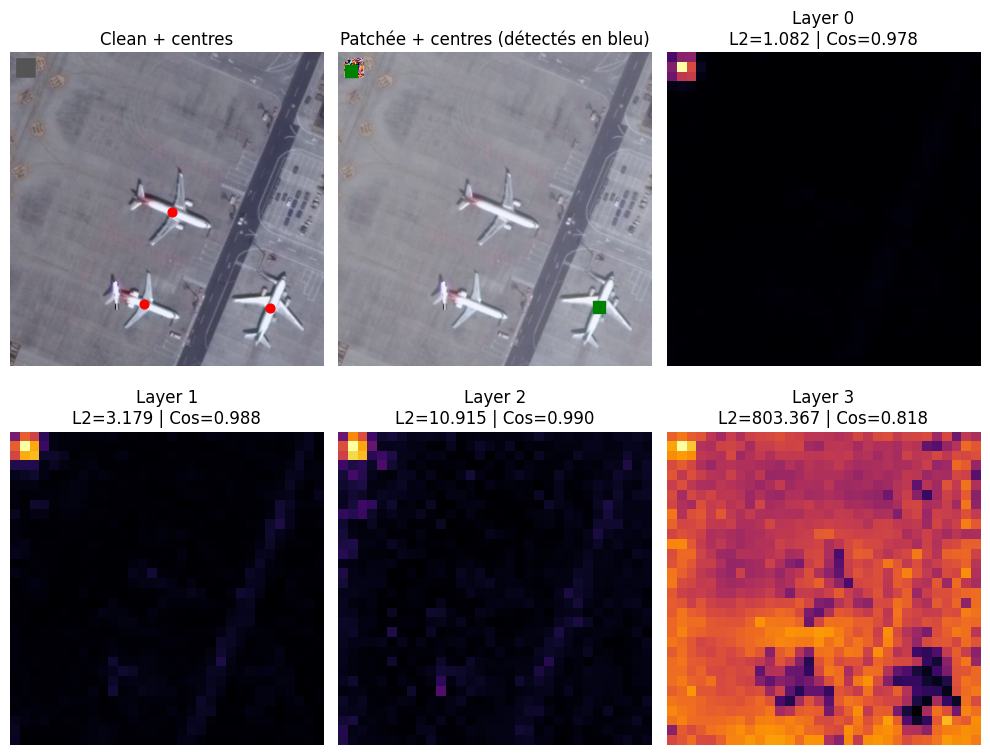

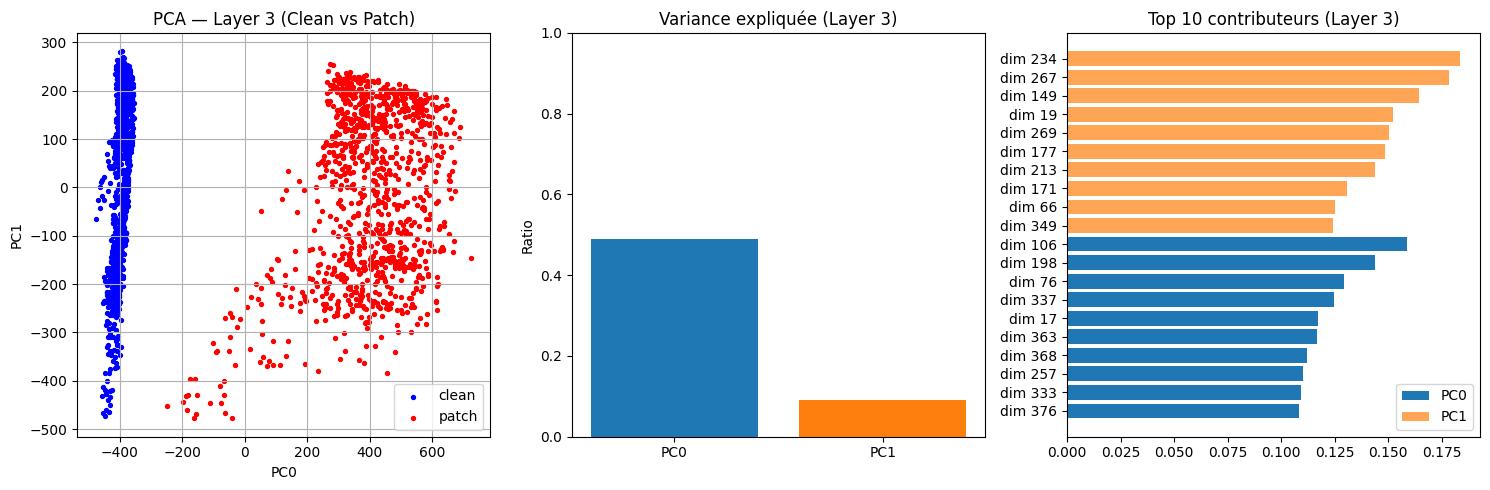

In [156]:
cfg2 = {
    "name": "patch32_divulse_version3",
    "path": "attack_results/27_02-23_21_24_divulse-stern/patch32_distilled.pt",
    "size": 32,
    "px": 10,
    "py": 10,
    "threshold": 0.3,
    "checkpoint": "runs/18_02-12_57_10_SMALL-PLUS_divulse-stern.pth",
    "image_id": "P2550_obj_6",
    "data_dir": "data/DOTA/DOTA_PLANES_TILED",
    "model_size": "small-plus",
    "device": "cuda",
    "return_embeddings": True
}
stats_32_3_img6, img, meta = visu_embeddings(cfg2)
stats = stats_32_3_img6
visualize_all_with_centers_no_save(
    img_clean = img,
    img_patch = stats["img_patch"],
    feats_clean = stats["feats_clean"],
    feats_patch = stats["feats_patch"],
    centers_clean = stats["pred_clean"],
    centers_patch = stats["pred_patched"],
    tile_id = cfg2["image_id"]
)
visualize_pca_layer3_with_contrib(
    stats["feats_clean"],
    stats["feats_patch"]
)


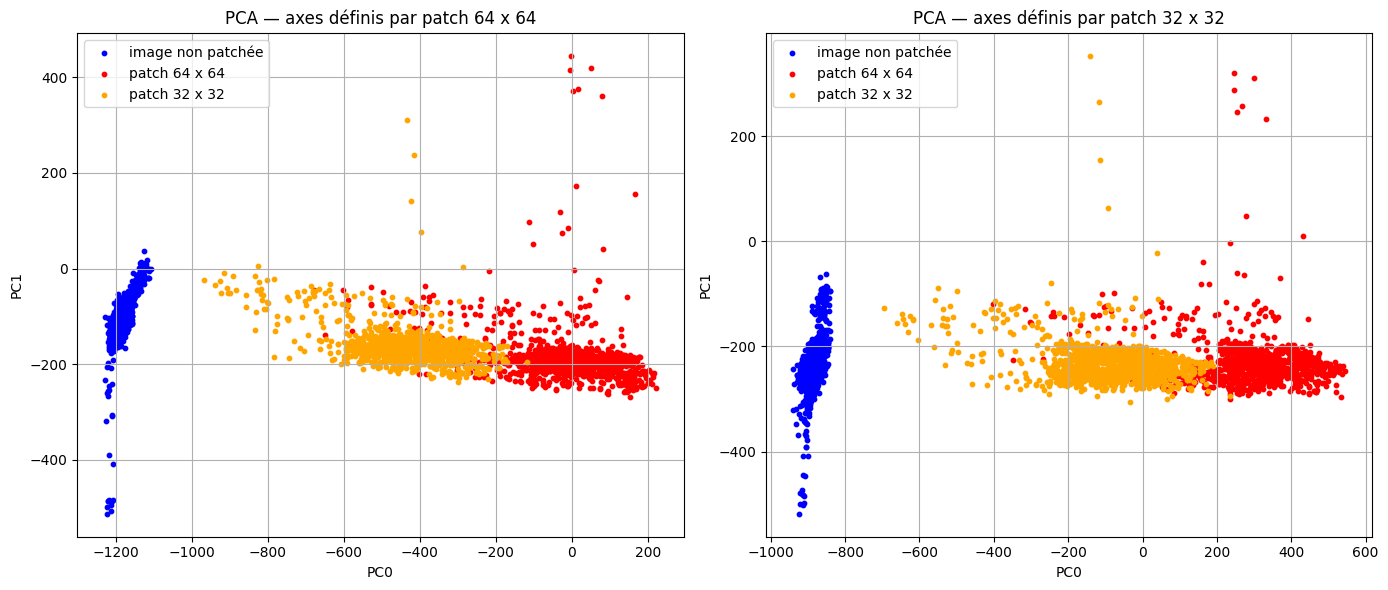

In [157]:
pca_two_patch(
    clean_A = stats_64_img6["feats_clean"][3],
    patch_A = stats_64_img6["feats_patch"][3],
    clean_B = stats_32_3_img6["feats_clean"][3],
    patch_B = stats_32_3_img6["feats_patch"][3],
    label_A="patch 64 x 64",
    label_B="patch 32 x 32"
)

Après 160 epochs (lr = 0.01 et lambda pour cos_similarity = 0.01 pour les 20 dernières)

In [172]:
cfg = {
        "name": "patch32_divulse_3b",
        "path": "attack_results/28_02-10_29_51_divulse-stern/patch32_distilled.pt",  # 28_02-20_09_12_divulse-stern/patch32_distilled.pt",   # 28_02-10_29_51_divulse-stern/patch32_distilled.pt",
        "size": 32,
        "px": 10,
        "py": 10,
        "threshold": 0.3,
        "checkpoint": "runs/18_02-12_57_10_SMALL-PLUS_divulse-stern.pth"
    }

attack(cfg)


=== Evaluating patch32_divulse_3b ===


Loading weights:   0%|          | 0/235 [00:00<?, ?it/s]

eval: 100%|██████████| 147/147 [00:39<00:00,  3.73it/s]


Image     |   GT | clean | patched | recall clean → patched
------------------------------------------------------------
P2269     |    3 |     3 |       0 |   1.00 → 0.00
P2288     |  206 |   153 |      99 |   0.74 → 0.48
P2523     |   16 |    16 |      16 |   1.00 → 1.00
P2550     |   67 |    61 |       4 |   0.91 → 0.06
P2551     |  321 |   277 |     113 |   0.86 → 0.35
P2552     |  215 |   200 |     111 |   0.93 → 0.52
P2553     |  161 |   143 |      58 |   0.89 → 0.36
P2554     |  215 |   203 |     127 |   0.94 → 0.59
P2557     |   63 |    58 |      22 |   0.92 → 0.35
P2558     |  391 |   385 |      99 |   0.98 → 0.25
P2560     |  288 |   270 |     142 |   0.94 → 0.49
P2600     |   45 |    44 |      41 |   0.98 → 0.91
P2665     |    6 |     6 |       2 |   1.00 → 0.33
P2682     |   28 |    24 |      18 |   0.86 → 0.64
P2691     |  392 |   358 |      72 |   0.91 → 0.18
P2741     |    1 |     0 |       0 |   0.00 → 0.00
P2746     |   18 |    16 |       3 |   0.89 → 0.17
P2748     | 

In [268]:
cfg = {
        "name": "patch32_divulse_3b",
        "path": "attack_results/28_02-10_29_51_divulse-stern/patch32_distilled.pt",  # 28_02-20_09_12_divulse-stern/patch32_distilled.pt",   # 28_02-10_29_51_divulse-stern/patch32_distilled.pt",
        "size": 32,
        "px": 11,
        "py": 11,
        "threshold": 0.3,
        "checkpoint": "runs/18_02-12_57_10_SMALL-PLUS_divulse-stern.pth"
    }

attack(cfg)


=== Evaluating patch32_divulse_3b ===


Loading weights:   0%|          | 0/235 [00:00<?, ?it/s]

eval: 100%|██████████| 147/147 [00:38<00:00,  3.78it/s]

Image     |   GT | clean | patched | recall clean → patched
------------------------------------------------------------
P2269     |    3 |     3 |       3 |   1.00 → 1.00
P2288     |  206 |   153 |     149 |   0.74 → 0.72
P2523     |   16 |    16 |      16 |   1.00 → 1.00
P2550     |   67 |    61 |      62 |   0.91 → 0.93
P2551     |  321 |   277 |     274 |   0.86 → 0.85
P2552     |  215 |   200 |     200 |   0.93 → 0.93
P2553     |  161 |   143 |     143 |   0.89 → 0.89
P2554     |  215 |   203 |     201 |   0.94 → 0.93
P2557     |   63 |    58 |      60 |   0.92 → 0.95
P2558     |  391 |   385 |     383 |   0.98 → 0.98
P2560     |  288 |   270 |     269 |   0.94 → 0.93
P2600     |   45 |    44 |      43 |   0.98 → 0.96
P2665     |    6 |     6 |       6 |   1.00 → 1.00
P2682     |   28 |    24 |      23 |   0.86 → 0.82
P2691     |  392 |   358 |     351 |   0.91 → 0.90
P2741     |    1 |     0 |       0 |   0.00 → 0.00
P2746     |   18 |    16 |      16 |   0.89 → 0.89
P2748     | 

Image shape: torch.Size([1, 3, 512, 512])


Loading weights:   0%|          | 0/235 [00:00<?, ?it/s]

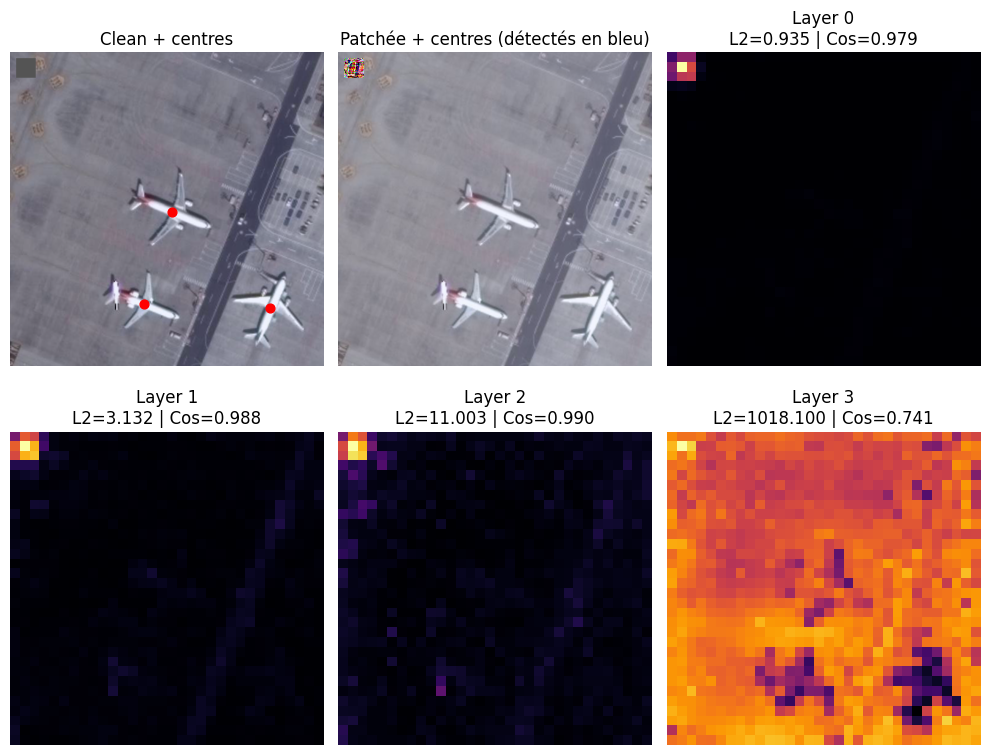

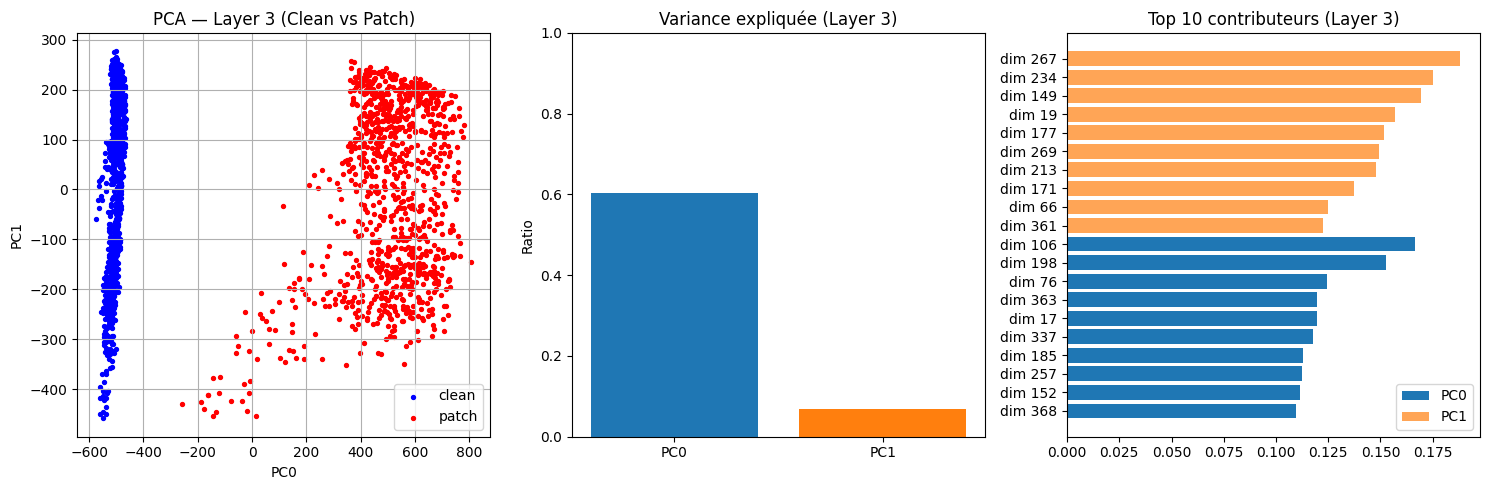

In [161]:
cfg2 = {
    "name": "patch32_divulse_version3b",
    "path": "attack_results/28_02-10_29_51_divulse-stern/patch32_distilled.pt",
    "size": 32,
    "px": 10,
    "py": 10,
    "threshold": 0.3,
    "checkpoint": "runs/18_02-12_57_10_SMALL-PLUS_divulse-stern.pth",
    "image_id": "P2550_obj_6",
    "data_dir": "data/DOTA/DOTA_PLANES_TILED",
    "model_size": "small-plus",
    "device": "cuda",
    "return_embeddings": True
}
stats_32_3b_img6, img, meta = visu_embeddings(cfg2)
stats = stats_32_3b_img6
visualize_all_with_centers_no_save(
    img_clean = img,
    img_patch = stats["img_patch"],
    feats_clean = stats["feats_clean"],
    feats_patch = stats["feats_patch"],
    centers_clean = stats["pred_clean"],
    centers_patch = stats["pred_patched"],
    tile_id = cfg2["image_id"]
)
visualize_pca_layer3_with_contrib(
    stats["feats_clean"],
    stats["feats_patch"]
)


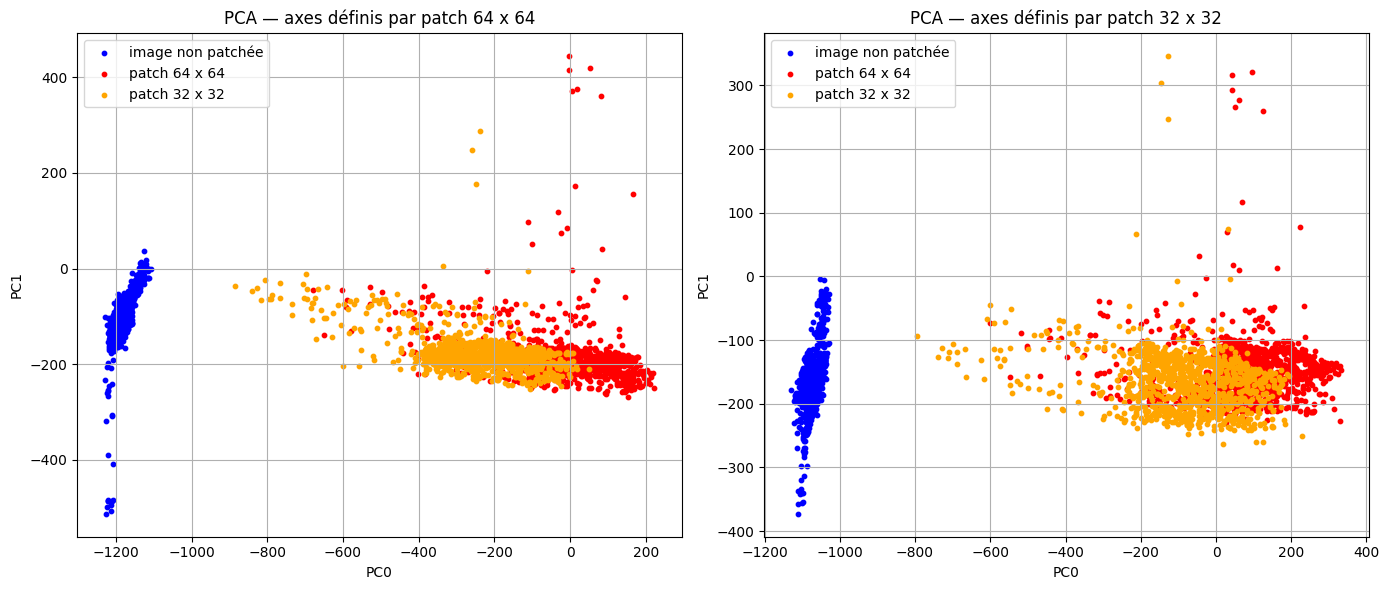

In [162]:
pca_two_patch(
    clean_A = stats_64_img6["feats_clean"][3],
    patch_A = stats_64_img6["feats_patch"][3],
    clean_B = stats_32_3b_img6["feats_clean"][3],
    patch_B = stats_32_3b_img6["feats_patch"][3],
    label_A="patch 64 x 64",
    label_B="patch 32 x 32"
)

## Patch 32 x 32 distillé vers patch 64 x 64 par PCA multi images

In [264]:
cfg = {
        "name": "patch32_divulse_multi_img",
        "path": "attack_results/28_02-22_08_35_divulse-stern/patch32_distilled.pt",
        "size": 32,
        "px": 10,
        "py": 10,
        "threshold": 0.3,
        "checkpoint": "runs/18_02-12_57_10_SMALL-PLUS_divulse-stern.pth"
    }

attack(cfg)


=== Evaluating patch32_divulse_multi_img ===


Loading weights:   0%|          | 0/235 [00:00<?, ?it/s]

eval: 100%|██████████| 147/147 [00:38<00:00,  3.77it/s]

Image     |   GT | clean | patched | recall clean → patched
------------------------------------------------------------
P2269     |    3 |     3 |       0 |   1.00 → 0.00
P2288     |  206 |   153 |      96 |   0.74 → 0.47
P2523     |   16 |    16 |      16 |   1.00 → 1.00
P2550     |   67 |    61 |       2 |   0.91 → 0.03
P2551     |  321 |   277 |      60 |   0.86 → 0.19
P2552     |  215 |   200 |      78 |   0.93 → 0.36
P2553     |  161 |   143 |      40 |   0.89 → 0.25
P2554     |  215 |   203 |      90 |   0.94 → 0.42
P2557     |   63 |    58 |      11 |   0.92 → 0.17
P2558     |  391 |   385 |      63 |   0.98 → 0.16
P2560     |  288 |   270 |      92 |   0.94 → 0.32
P2600     |   45 |    44 |      33 |   0.98 → 0.73
P2665     |    6 |     6 |       1 |   1.00 → 0.17
P2682     |   28 |    24 |      18 |   0.86 → 0.64
P2691     |  392 |   358 |      51 |   0.91 → 0.13
P2741     |    1 |     0 |       0 |   0.00 → 0.00
P2746     |   18 |    16 |       2 |   0.89 → 0.11
P2748     | 

Image shape: torch.Size([1, 3, 512, 512])


Loading weights:   0%|          | 0/235 [00:00<?, ?it/s]

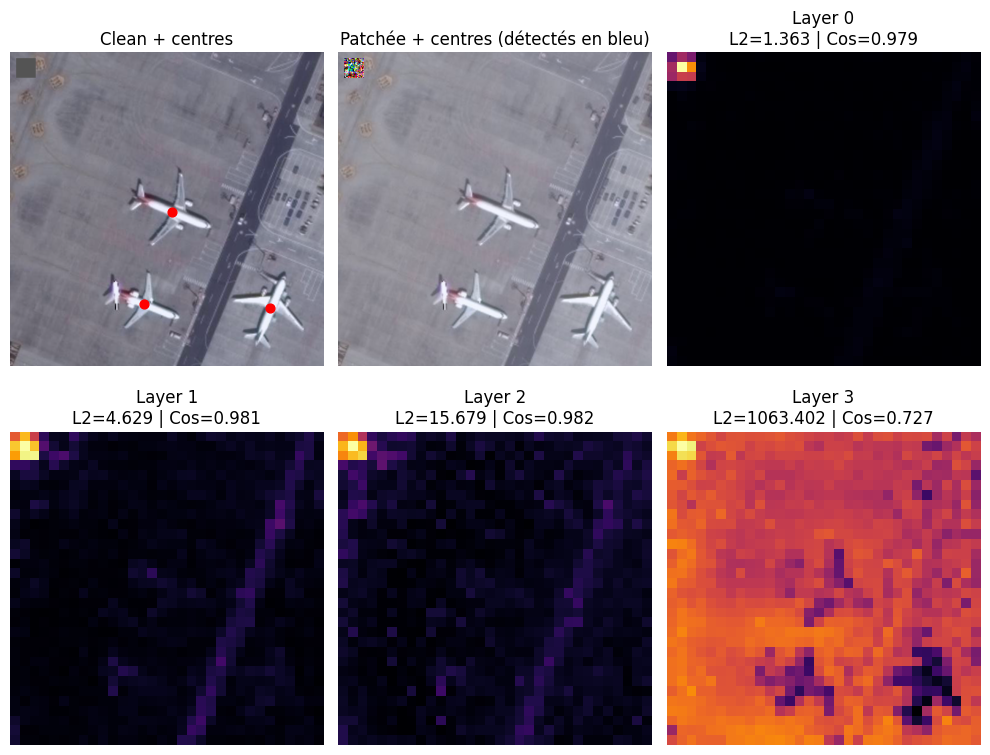

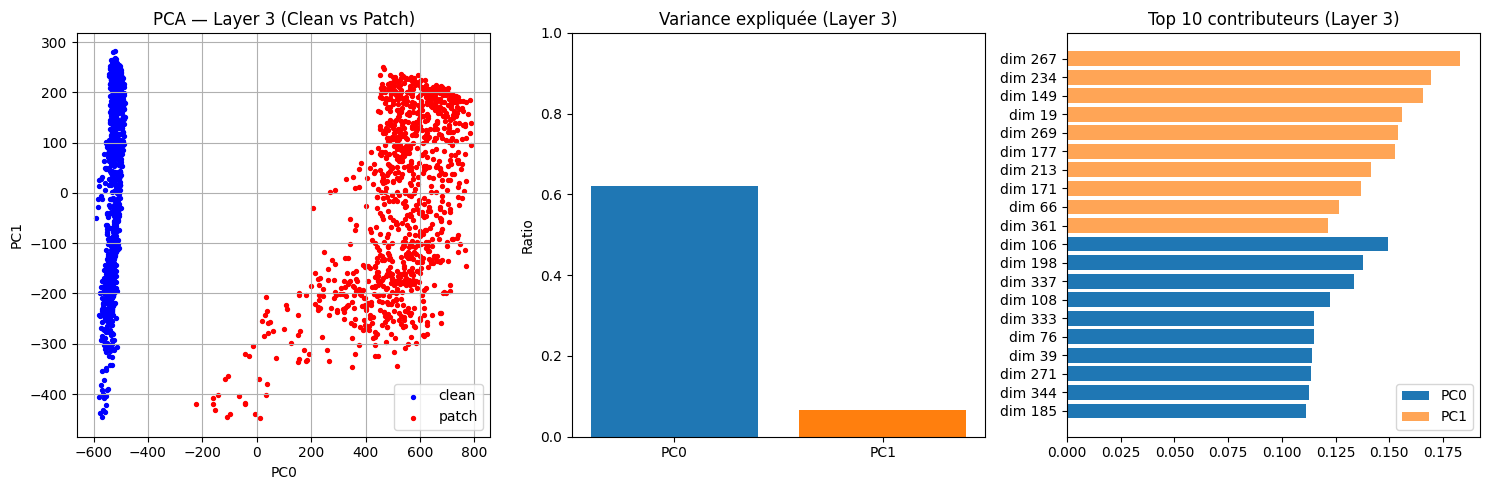

In [265]:
cfg2 = {
    "name": "patch32_divulse_version_multi_image",
    "path": "attack_results/28_02-22_08_35_divulse-stern/patch32_distilled.pt",
    "size": 32,
    "px": 10,
    "py": 10,
    "threshold": 0.3,
    "checkpoint": "runs/18_02-12_57_10_SMALL-PLUS_divulse-stern.pth",
    "image_id": "P2550_obj_6",
    "data_dir": "data/DOTA/DOTA_PLANES_TILED",
    "model_size": "small-plus",
    "device": "cuda",
    "return_embeddings": True
}
stats_32_multi_img6, img, meta = visu_embeddings(cfg2)
stats = stats_32_multi_img6
visualize_all_with_centers_no_save(
    img_clean = img,
    img_patch = stats["img_patch"],
    feats_clean = stats["feats_clean"],
    feats_patch = stats["feats_patch"],
    centers_clean = stats["pred_clean"],
    centers_patch = stats["pred_patched"],
    tile_id = cfg2["image_id"]
)
visualize_pca_layer3_with_contrib(
    stats["feats_clean"],
    stats["feats_patch"]
)


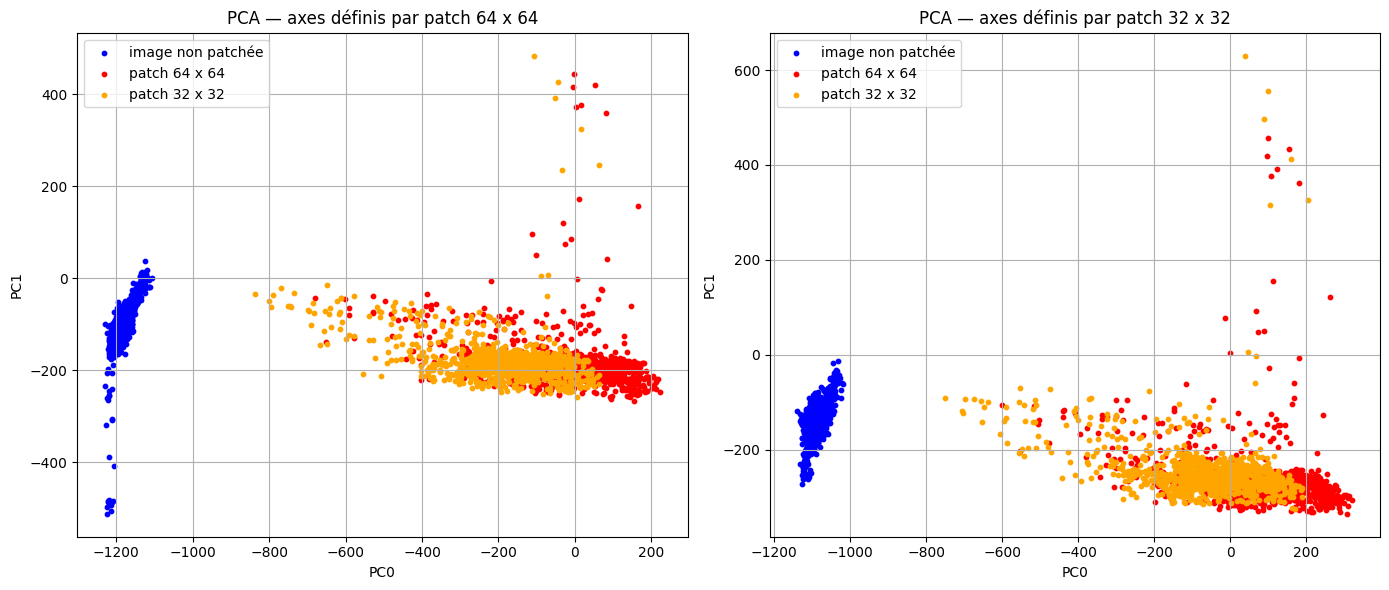

In [266]:
pca_two_patch(
    clean_A = stats_64_img6["feats_clean"][3],
    patch_A = stats_64_img6["feats_patch"][3],
    clean_B = stats_32_multi_img6["feats_clean"][3],
    patch_B = stats_32_multi_img6["feats_patch"][3],
    label_A="patch 64 x 64",
    label_B="patch 32 x 32"
)

In [267]:
cfg = {
        "name": "patch32_divulse_multi_img",
        "path": "attack_results/28_02-22_08_35_divulse-stern/patch32_distilled.pt",
        "size": 32,
        "px": 11,
        "py": 11,
        "threshold": 0.3,
        "checkpoint": "runs/18_02-12_57_10_SMALL-PLUS_divulse-stern.pth"
    }

attack(cfg)


=== Evaluating patch32_divulse_multi_img ===


Loading weights:   0%|          | 0/235 [00:00<?, ?it/s]

eval: 100%|██████████| 147/147 [00:40<00:00,  3.66it/s]

Image     |   GT | clean | patched | recall clean → patched
------------------------------------------------------------
P2269     |    3 |     3 |       3 |   1.00 → 1.00
P2288     |  206 |   153 |     153 |   0.74 → 0.74
P2523     |   16 |    16 |      16 |   1.00 → 1.00
P2550     |   67 |    61 |      62 |   0.91 → 0.93
P2551     |  321 |   277 |     273 |   0.86 → 0.85
P2552     |  215 |   200 |     199 |   0.93 → 0.93
P2553     |  161 |   143 |     143 |   0.89 → 0.89
P2554     |  215 |   203 |     201 |   0.94 → 0.93
P2557     |   63 |    58 |      59 |   0.92 → 0.94
P2558     |  391 |   385 |     384 |   0.98 → 0.98
P2560     |  288 |   270 |     268 |   0.94 → 0.93
P2600     |   45 |    44 |      43 |   0.98 → 0.96
P2665     |    6 |     6 |       6 |   1.00 → 1.00
P2682     |   28 |    24 |      24 |   0.86 → 0.86
P2691     |  392 |   358 |     354 |   0.91 → 0.90
P2741     |    1 |     0 |       0 |   0.00 → 0.00
P2746     |   18 |    16 |      16 |   0.89 → 0.89
P2748     | 

Dernier essai de patch 32 x 32 300 epochs à la 251 : loss = 401612

In [272]:
cfg = {
        "name": "patch32_divulse_multi_img",
        "path": "attack_results/01_03-09_54_05_divulse-stern/patch32_distilled.pt",
        "size": 32,
        "px": 10,
        "py": 10,
        "threshold": 0.3,
        "checkpoint": "runs/18_02-12_57_10_SMALL-PLUS_divulse-stern.pth"
    }

attack(cfg)


=== Evaluating patch32_divulse_multi_img ===


Loading weights:   0%|          | 0/235 [00:00<?, ?it/s]

eval: 100%|██████████| 147/147 [00:39<00:00,  3.76it/s]

Image     |   GT | clean | patched | recall clean → patched
------------------------------------------------------------
P2269     |    3 |     3 |       0 |   1.00 → 0.00
P2288     |  206 |   153 |      87 |   0.74 → 0.42
P2523     |   16 |    16 |      14 |   1.00 → 0.88
P2550     |   67 |    61 |       2 |   0.91 → 0.03
P2551     |  321 |   277 |      35 |   0.86 → 0.11
P2552     |  215 |   200 |      60 |   0.93 → 0.28
P2553     |  161 |   143 |      18 |   0.89 → 0.11
P2554     |  215 |   203 |      53 |   0.94 → 0.25
P2557     |   63 |    58 |       8 |   0.92 → 0.13
P2558     |  391 |   385 |      31 |   0.98 → 0.08
P2560     |  288 |   270 |      38 |   0.94 → 0.13
P2600     |   45 |    44 |      28 |   0.98 → 0.62
P2665     |    6 |     6 |       1 |   1.00 → 0.17
P2682     |   28 |    24 |      16 |   0.86 → 0.57
P2691     |  392 |   358 |      41 |   0.91 → 0.10
P2741     |    1 |     0 |       0 |   0.00 → 0.00
P2746     |   18 |    16 |       1 |   0.89 → 0.06
P2748     | 

Image shape: torch.Size([1, 3, 512, 512])


Loading weights:   0%|          | 0/235 [00:00<?, ?it/s]

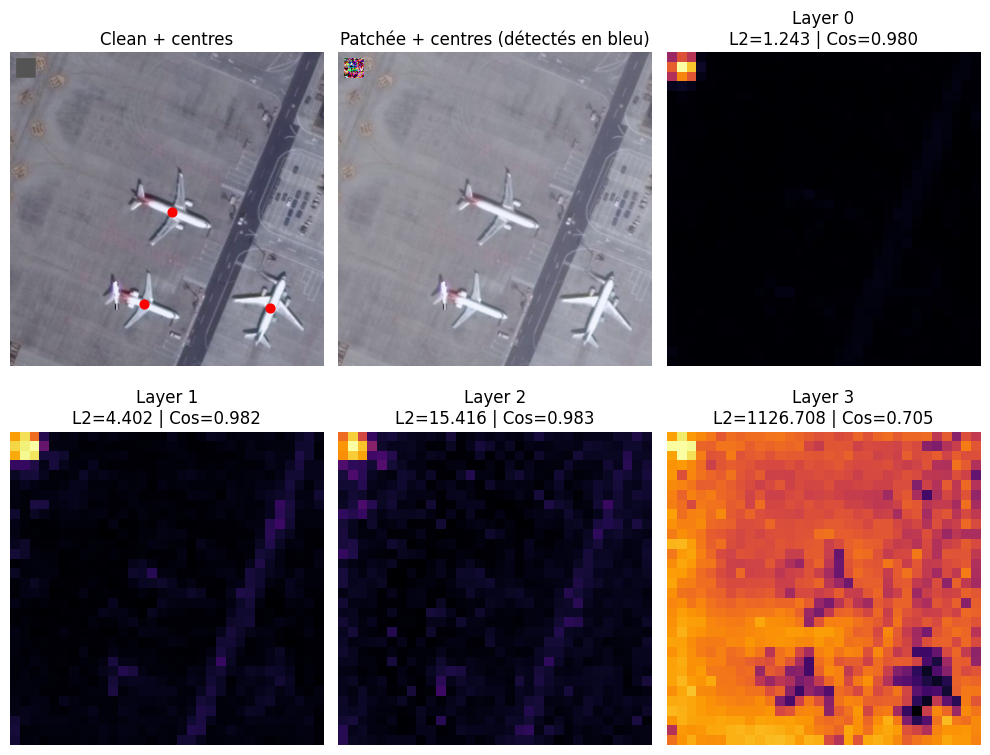

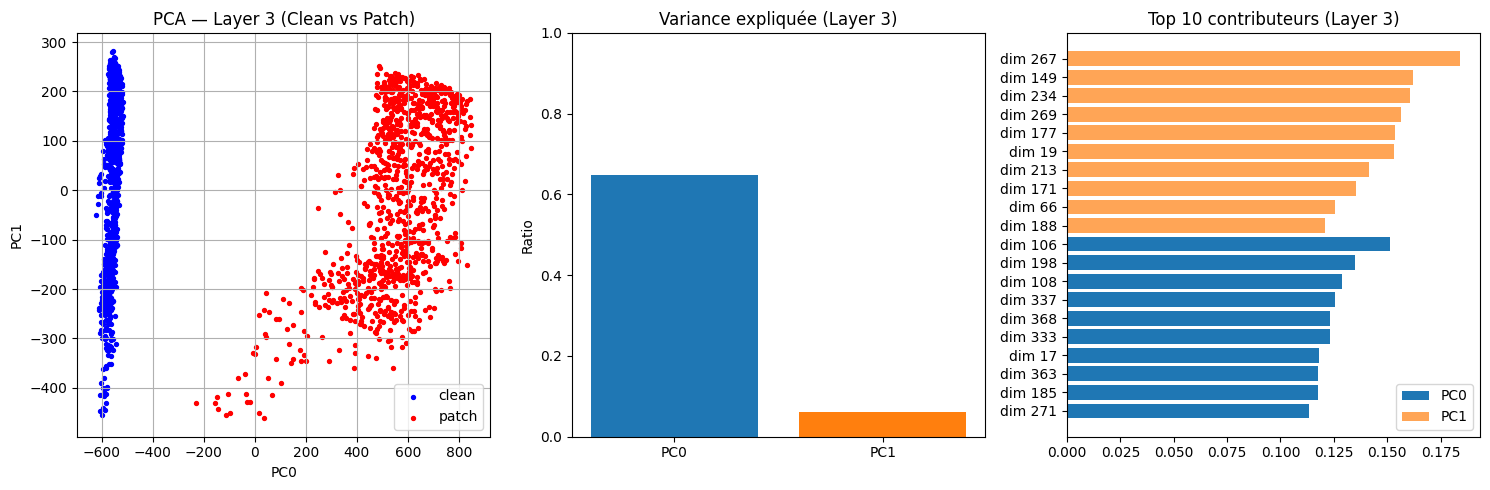

In [274]:
cfg2 = {
    "name": "patch32_divulse_version_multi_image",
    "path": "attack_results/01_03-09_54_05_divulse-stern/patch32_distilled.pt",
    "size": 32,
    "px": 10,
    "py": 10,
    "threshold": 0.3,
    "checkpoint": "runs/18_02-12_57_10_SMALL-PLUS_divulse-stern.pth",
    "image_id": "P2550_obj_6",
    "data_dir": "data/DOTA/DOTA_PLANES_TILED",
    "model_size": "small-plus",
    "device": "cuda",
    "return_embeddings": True
}
stats_32_multi_2_img6, img, meta = visu_embeddings(cfg2)
stats = stats_32_multi_2_img6
visualize_all_with_centers_no_save(
    img_clean = img,
    img_patch = stats["img_patch"],
    feats_clean = stats["feats_clean"],
    feats_patch = stats["feats_patch"],
    centers_clean = stats["pred_clean"],
    centers_patch = stats["pred_patched"],
    tile_id = cfg2["image_id"]
)
visualize_pca_layer3_with_contrib(
    stats["feats_clean"],
    stats["feats_patch"]
)


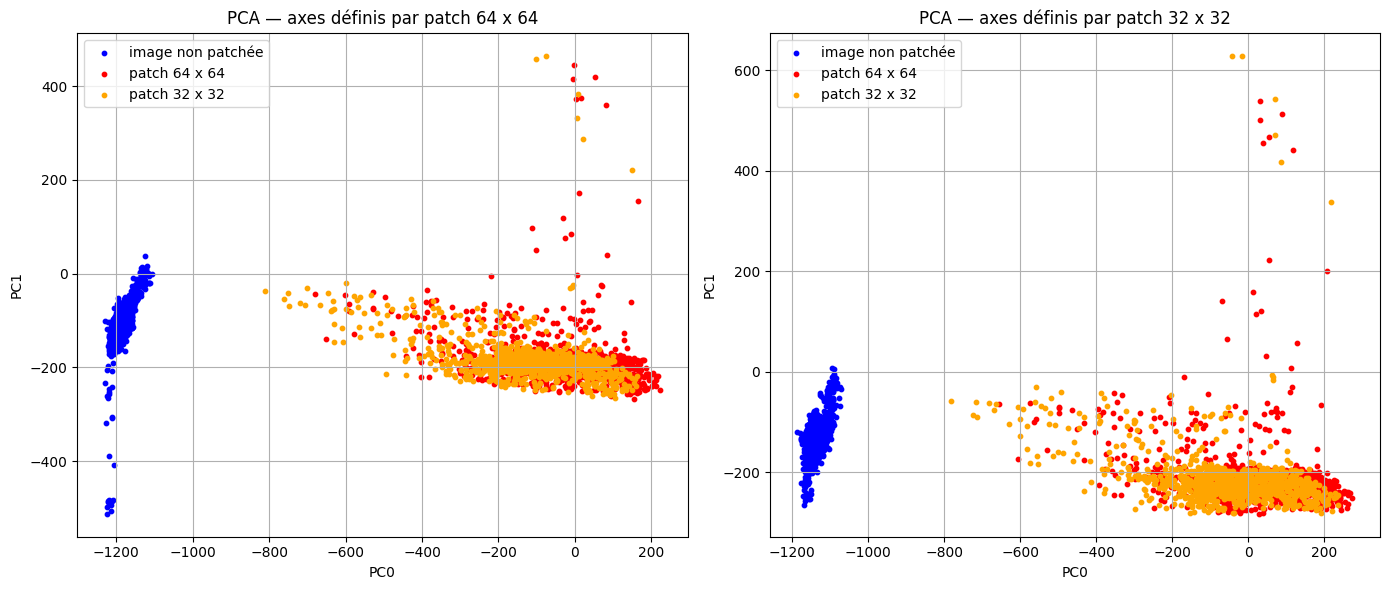

In [275]:
pca_two_patch(
    clean_A = stats_64_img6["feats_clean"][3],
    patch_A = stats_64_img6["feats_patch"][3],
    clean_B = stats_32_multi_2_img6["feats_clean"][3],
    patch_B = stats_32_multi_2_img6["feats_patch"][3],
    label_A="patch 64 x 64",
    label_B="patch 32 x 32"
)

In [276]:
cfg = {
        "name": "patch32_divulse_multi_img",
        "path": "attack_results/01_03-09_54_05_divulse-stern/patch32_distilled.pt",
        "size": 32,
        "px": 11,
        "py": 11,
        "threshold": 0.3,
        "checkpoint": "runs/18_02-12_57_10_SMALL-PLUS_divulse-stern.pth"
    }

attack(cfg)


=== Evaluating patch32_divulse_multi_img ===


Loading weights:   0%|          | 0/235 [00:00<?, ?it/s]

eval: 100%|██████████| 147/147 [00:39<00:00,  3.76it/s]

Image     |   GT | clean | patched | recall clean → patched
------------------------------------------------------------
P2269     |    3 |     3 |       3 |   1.00 → 1.00
P2288     |  206 |   153 |     152 |   0.74 → 0.74
P2523     |   16 |    16 |      16 |   1.00 → 1.00
P2550     |   67 |    61 |      62 |   0.91 → 0.93
P2551     |  321 |   277 |     274 |   0.86 → 0.85
P2552     |  215 |   200 |     198 |   0.93 → 0.92
P2553     |  161 |   143 |     142 |   0.89 → 0.88
P2554     |  215 |   203 |     200 |   0.94 → 0.93
P2557     |   63 |    58 |      59 |   0.92 → 0.94
P2558     |  391 |   385 |     384 |   0.98 → 0.98
P2560     |  288 |   270 |     268 |   0.94 → 0.93
P2600     |   45 |    44 |      43 |   0.98 → 0.96
P2665     |    6 |     6 |       6 |   1.00 → 1.00
P2682     |   28 |    24 |      23 |   0.86 → 0.82
P2691     |  392 |   358 |     355 |   0.91 → 0.91
P2741     |    1 |     0 |       0 |   0.00 → 0.00
P2746     |   18 |    16 |      16 |   0.89 → 0.89
P2748     | 